# 01_쿡앱스 데이터 확인하기

In [1]:
# import os
# import random #데이터 샘플링
# from collections import Counter # count 용도

import numpy as np
import pandas as pd

# from geopy import distance # 거리 계산
# import geopy.distance
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use('fivethirtyeight')

# 한글, 마이너스 깨짐 방지
from matplotlib import rc, font_manager, rcParams
font=font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family = font)
rcParams['axes.unicode_minus'] = False

## 데이터 불러오기

In [2]:
df = pd.read_csv('./dataset/UA_사전과제_ sample data (1).xlsx - Data.csv')
df.head()

,Source,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV
0,A,1.0,"$ 3,481.6",$ 14.04,"113,348",491,248,49.0,$ 715.14,$ 71.05,$ 2.17
1,A,2.0,"$ 2,804.0",$ 18.57,"92,149",359,151,26.0,$ 396.69,$ 107.84,$ 1.98
2,A,3.0,"$ 2,550.1",$ 15.36,"102,420",429,166,23.0,$ 277.39,$ 110.87,$ 1.30
3,B,1.0,"$ 1,826.6",$ 2.55,"349,493","11,691",717,1.0,$ 6.87,"$ 1,826.61",$ 0.16
4,B,2.0,"$ 1,417.9",$ 2.22,"321,994","11,797",640,2.0,$ 10.21,$ 708.95,$ 0.15


In [3]:
df.tail()

,Source,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV
18,G,1.0,"$ 4,200.0",$ 2.97,"286,913","56,981","1,416",13.0,$ 160.70,$ 323.08,$ 0.24
19,G,2.0,"$ 7,600.0",$ 3.18,"540,569","111,038","2,388",52.0,$ 488.66,$ 146.15,$ 0.29
20,G,3.0,"$ 6,800.0",$ 3.59,"638,409","100,261","1,892",19.0,$ 201.34,$ 357.89,$ 0.28
21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,* LTV를 포함한 모든 매출 관련 데이터는 D0 기준 입니다.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.isnull().sum()

Source               1
Week                 2
Spend                2
CPI                  2
Impression           2
Click                2
Install              2
Purchase             2
Sales                2
Cost per Purchase    2
LTV                  2
dtype: int64

In [5]:
df.dropna(inplace=True)

In [6]:
df

,Source,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV
0,A,1.0,"$ 3,481.6",$ 14.04,"113,348",491,248,49.0,$ 715.14,$ 71.05,$ 2.17
1,A,2.0,"$ 2,804.0",$ 18.57,"92,149",359,151,26.0,$ 396.69,$ 107.84,$ 1.98
2,A,3.0,"$ 2,550.1",$ 15.36,"102,420",429,166,23.0,$ 277.39,$ 110.87,$ 1.30
3,B,1.0,"$ 1,826.6",$ 2.55,"349,493","11,691",717,1.0,$ 6.87,"$ 1,826.61",$ 0.16
4,B,2.0,"$ 1,417.9",$ 2.22,"321,994","11,797",640,2.0,$ 10.21,$ 708.95,$ 0.15
5,B,3.0,"$ 1,452.5",$ 2.48,"325,825","11,748",585,1.0,$ 6.83,"$ 1,452.49",$ 0.14
6,C,1.0,$ 801.0,$ 2.72,"25,535",359,294,1.0,$ 6.61,$ 801.00,$ 0.18
7,C,2.0,$ 793.0,$ 2.59,"21,245",364,306,1.0,$ 5.76,$ 793.00,$ 0.18
8,C,3.0,"$ 1,171.0",$ 2.78,"39,080",516,421,2.0,$ 10.03,$ 585.50,$ 0.17
9,D,1.0,"$ 3,525.4",$ 3.93,"274,921","31,737",897,0.0,$ -,$ -,$ 0.21


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Source             21 non-null     object 
 1   Week               21 non-null     float64
 2   Spend              21 non-null     object 
 3   CPI                21 non-null     object 
 4   Impression         21 non-null     object 
 5   Click              21 non-null     object 
 6   Install            21 non-null     object 
 7   Purchase           21 non-null     float64
 8   Sales              21 non-null     object 
 9   Cost per Purchase  21 non-null     object 
 10  LTV                21 non-null     object 
dtypes: float64(2), object(9)
memory usage: 2.0+ KB


## 데이터 전처리

+ 문자열로 된 데이터를 전처리 후 숫자타입으로 변경

In [8]:
df['Spend'][1].strip()[2:]
df['CPI'][1].strip()[2:]
df['Impression'][1].strip()
df['Click'][1].strip()
df['Install'][1].strip()
df['Sales'][1].strip()[2:]
df['Cost per Purchase'][1].strip()[2:]
df['LTV'][1].strip()[2:]

'1.98'

In [9]:
for index in df.index:
    df['Spend'][index] = df['Spend'][index].strip()[2:].replace(',', '')
    df['CPI'][index] = df['CPI'][index].strip()[2:]
    df['Impression'][index] = df['Impression'][index].strip().replace(',', '')
    df['Click'][index] = df['Click'][index].strip().replace(',', '')
    df['Install'][index] = df['Install'][index].strip().replace(',', '')
    df['Sales'][index] = df['Sales'][index].strip()[2:].replace(',', '')
    df['Cost per Purchase'][index] = df['Cost per Purchase'][index].strip()[2:].replace(',', '')
    df['LTV'][index] = df['LTV'][index].strip()[2:]
print('완료')

완료


In [10]:
df

,Source,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV
0,A,1.0,3481.6,14.04,113348,491,248,49.0,715.14,71.05,2.17
1,A,2.0,2804.0,18.57,92149,359,151,26.0,396.69,107.84,1.98
2,A,3.0,2550.1,15.36,102420,429,166,23.0,277.39,110.87,1.30
3,B,1.0,1826.6,2.55,349493,11691,717,1.0,6.87,1826.61,0.16
4,B,2.0,1417.9,2.22,321994,11797,640,2.0,10.21,708.95,0.15
5,B,3.0,1452.5,2.48,325825,11748,585,1.0,6.83,1452.49,0.14
6,C,1.0,801.0,2.72,25535,359,294,1.0,6.61,801.00,0.18
7,C,2.0,793.0,2.59,21245,364,306,1.0,5.76,793.00,0.18
8,C,3.0,1171.0,2.78,39080,516,421,2.0,10.03,585.50,0.17
9,D,1.0,3525.4,3.93,274921,31737,897,0.0,-,-,0.21


In [11]:
# -를 0으로 변경해주기
df.loc[9, ['Sales', 'Cost per Purchase']] = '0'

In [12]:
df

,Source,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV
0,A,1.0,3481.6,14.04,113348,491,248,49.0,715.14,71.05,2.17
1,A,2.0,2804.0,18.57,92149,359,151,26.0,396.69,107.84,1.98
2,A,3.0,2550.1,15.36,102420,429,166,23.0,277.39,110.87,1.30
3,B,1.0,1826.6,2.55,349493,11691,717,1.0,6.87,1826.61,0.16
4,B,2.0,1417.9,2.22,321994,11797,640,2.0,10.21,708.95,0.15
5,B,3.0,1452.5,2.48,325825,11748,585,1.0,6.83,1452.49,0.14
6,C,1.0,801.0,2.72,25535,359,294,1.0,6.61,801.00,0.18
7,C,2.0,793.0,2.59,21245,364,306,1.0,5.76,793.00,0.18
8,C,3.0,1171.0,2.78,39080,516,421,2.0,10.03,585.50,0.17
9,D,1.0,3525.4,3.93,274921,31737,897,0.0,0,0,0.21


In [13]:
# 타입 변경하기
df['Week'] = df['Week'].astype('int')
df['Spend'] = df['Spend'].astype('float')
df['CPI'] = df['CPI'].astype('float')
df['Impression'] = df['Impression'].astype('int')
df['Click'] = df['Click'].astype('int')
df['Install'] = df['Install'].astype('int')
df['Sales'] = df['Sales'].astype('float')
df['Cost per Purchase'] = df['Cost per Purchase'].astype('float')
df['LTV'] = df['LTV'].astype('float')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Source             21 non-null     object 
 1   Week               21 non-null     int32  
 2   Spend              21 non-null     float64
 3   CPI                21 non-null     float64
 4   Impression         21 non-null     int32  
 5   Click              21 non-null     int32  
 6   Install            21 non-null     int32  
 7   Purchase           21 non-null     float64
 8   Sales              21 non-null     float64
 9   Cost per Purchase  21 non-null     float64
 10  LTV                21 non-null     float64
dtypes: float64(6), int32(4), object(1)
memory usage: 2.2+ KB


+ 변경 완료!

## 데이터 분석하기

In [15]:
df.describe()

,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV
count,21.00000,21.000000,21.000000,2.100000e+01,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000
mean,2.00000,3112.628571,6.844762,4.739738e+05,21345.095238,664.428571,19.904762,268.387619,447.297143,0.698095
std,0.83666,2141.422444,5.103903,8.890331e+05,31866.022055,595.873524,23.534878,335.289408,492.235495,0.677507
min,1.00000,793.000000,2.220000,2.124500e+04,359.000000,95.000000,0.000000,0.000000,0.000000,0.140000
25%,1.00000,1452.500000,2.780000,9.214900e+04,504.000000,248.000000,2.000000,10.030000,107.840000,0.180000
50%,2.00000,2550.100000,4.120000,1.496530e+05,11748.000000,578.000000,13.000000,160.700000,209.110000,0.290000
75%,3.00000,4200.000000,9.850000,3.494930e+05,21113.000000,717.000000,32.000000,452.560000,708.950000,1.130000
max,3.00000,8103.400000,18.570000,4.113927e+06,111038.000000,2388.000000,94.000000,1386.940000,1826.610000,2.170000


In [16]:
df.sum()

Source               AAABBBCCCDDDEEEFFFGGG
Week                                    42
Spend                              65365.2
CPI                                 143.74
Impression                         9953449
Click                               448247
Install                              13953
Purchase                             418.0
Sales                              5636.14
Cost per Purchase                  9393.24
LTV                                  14.66
dtype: object

In [17]:
# 소스로 묶어서 확인하기
df.groupby('Source').mean()

,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV
Source,,,,,,,,,,
A,2.0,2945.233333,15.990000,1.026390e+05,426.333333,188.333333,32.666667,463.073333,96.586667,1.816667
B,2.0,1565.666667,2.416667,3.324373e+05,11745.333333,647.333333,1.333333,7.970000,1329.350000,0.150000
C,2.0,921.666667,2.696667,2.862000e+04,413.000000,340.333333,1.333333,7.466667,726.500000,0.176667
D,2.0,2826.933333,4.210000,1.673300e+05,21791.666667,675.000000,3.000000,59.953333,463.680000,0.256667
E,2.0,1816.566667,12.026667,1.183653e+05,733.666667,156.333333,20.333333,292.530000,122.670000,1.363333
F,2.0,5512.333333,7.326667,2.079794e+06,24879.000000,745.000000,52.666667,764.153333,116.586667,0.853333
G,2.0,6200.000000,3.246667,4.886303e+05,89426.666667,1898.666667,28.000000,283.566667,275.706667,0.270000


In [18]:
df.groupby('Source').sum()

,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV
Source,,,,,,,,,,
A,6,8835.7,47.97,307917,1279,565,98.0,1389.22,289.76,5.45
B,6,4697.0,7.25,997312,35236,1942,4.0,23.91,3988.05,0.45
C,6,2765.0,8.09,85860,1239,1021,4.0,22.40,2179.50,0.53
D,6,8480.8,12.63,501990,65375,2025,9.0,179.86,1391.04,0.77
E,6,5449.7,36.08,355096,2201,469,61.0,877.59,368.01,4.09
F,6,16537.0,21.98,6239383,74637,2235,158.0,2292.46,349.76,2.56
G,6,18600.0,9.74,1465891,268280,5696,84.0,850.70,827.12,0.81


In [19]:
df.groupby(['Source', 'Week']).sum()

Spend    CPI  Impression   Click  Install  Purchase    Sales  \
Source Week                                                                  
A      1     3481.6  14.04      113348     491      248      49.0   715.14   
       2     2804.0  18.57       92149     359      151      26.0   396.69   
       3     2550.1  15.36      102420     429      166      23.0   277.39   
B      1     1826.6   2.55      349493   11691      717       1.0     6.87   
       2     1417.9   2.22      321994   11797      640       2.0    10.21   
       3     1452.5   2.48      325825   11748      585       1.0     6.83   
C      1      801.0   2.72       25535     359      294       1.0     6.61   
       2      793.0   2.59       21245     364      306       1.0     5.76   
       3     1171.0   2.78       39080     516      421       2.0    10.03   
D      1     3525.4   3.93      274921   31737      897       0.0     0.00   
       2     3042.7   4.58      149653   21113      664       7.0   145.26   
       3     1912.7   4.12       77416   12525      464       2.0    34.60   
E      1     2098.0   9.85      131223     889      213      33.0   526.14   
       2     2097.0  13.02      138881     808      161      22.0   263.26   
       3     1254.7  13.21       84992     504       95       6.0    88.19   
F      1     8103.4   7.69     4113927   40306     1054      94.0  1386.94   
       2     4216.6   7.30      911325   15190      578      32.0   452.56   
       3     4217.0   6.99     1214131   19141      603      32.0   452.96   
G      1     4200.0   2.97      286913   56981     1416      13.0   160.70   
       2     7600.0   3.18      540569  111038     2388      52.0   488.66   
       3     6800.0   3.59      638409  100261     1892      19.0   201.34   

             Cost per Purchase   LTV  
Source Week                           
A      1                 71.05  2.17  
       2                107.84  1.98  
       3                110.87  1.30  
B      1               1826.61  0.16  
       2                708.95  0.15  
       3               1452.49  0.14  
C      1                801.00  0.18  
       2                793.00  0.18  
       3                585.50  0.17  
D      1                  0.00  0.21  
       2                434.68  0.34  
       3                956.36  0.22  
E      1                 63.58  1.94  
       2                 95.32  1.33  
       3                209.11  0.82  
F      1                 86.21  1.13  
       2                131.77  0.74  
       3                131.78  0.69  
G      1                323.08  0.24  
       2                146.15  0.29  
       3                357.89  0.28

In [20]:
# ROAS 구해보기
df_roas = df.groupby('Source').sum()
df_roas['ROAS'] = np.nan
df_roas['ROAS'] = df_roas['Sales'] / df_roas['Spend'] * 100
df_roas

,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV,ROAS
Source,,,,,,,,,,,
A,6,8835.7,47.97,307917,1279,565,98.0,1389.22,289.76,5.45,15.722806
B,6,4697.0,7.25,997312,35236,1942,4.0,23.91,3988.05,0.45,0.509048
C,6,2765.0,8.09,85860,1239,1021,4.0,22.40,2179.50,0.53,0.810127
D,6,8480.8,12.63,501990,65375,2025,9.0,179.86,1391.04,0.77,2.120790
E,6,5449.7,36.08,355096,2201,469,61.0,877.59,368.01,4.09,16.103455
F,6,16537.0,21.98,6239383,74637,2235,158.0,2292.46,349.76,2.56,13.862611
G,6,18600.0,9.74,1465891,268280,5696,84.0,850.70,827.12,0.81,4.573656


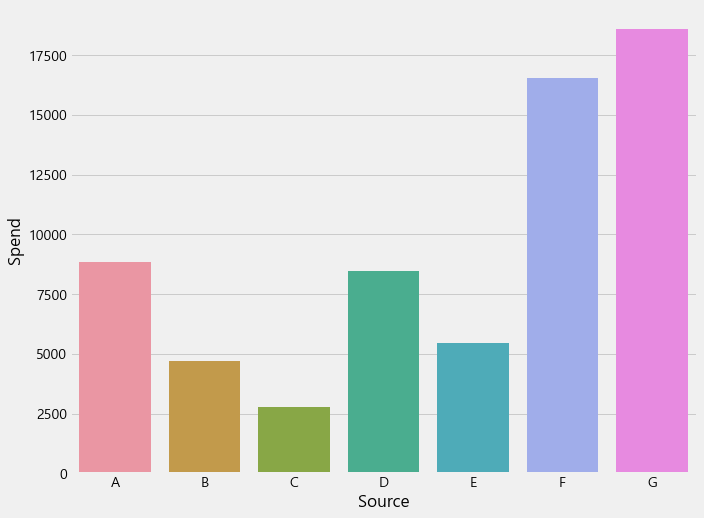

In [21]:
# 소스별 데이터 비교
# Spend
plt.figure(figsize=(10, 8))
df_by_group_label = df_roas.reset_index()
sns.barplot(x='Source', y='Spend', data=df_by_group_label)
plt.show()

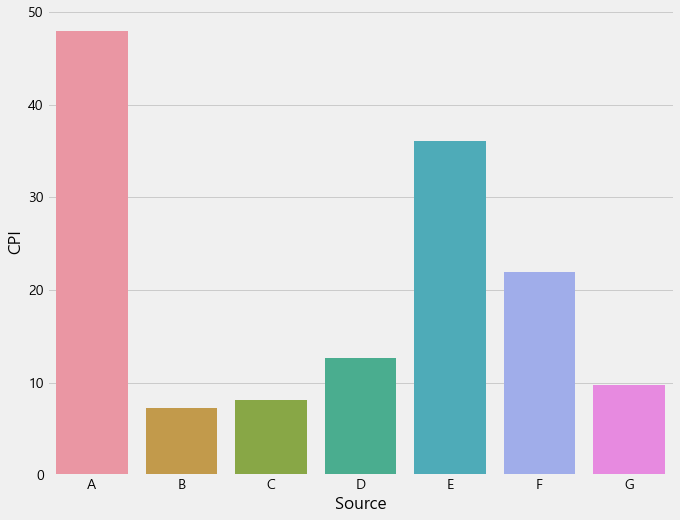

In [22]:
# CPI
plt.figure(figsize=(10, 8))
df_by_group_label = df_roas.reset_index()
sns.barplot(x='Source', y='CPI', data=df_by_group_label)
plt.show()

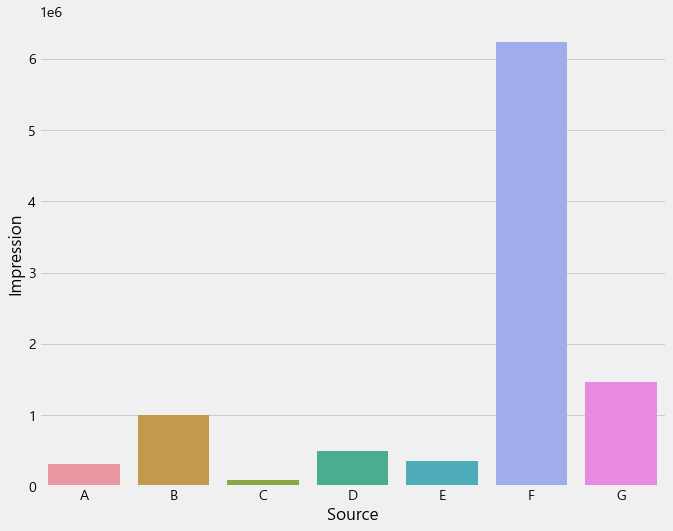

In [23]:
# Impression
plt.figure(figsize=(10, 8))
df_by_group_label = df_roas.reset_index()
sns.barplot(x='Source', y='Impression', data=df_by_group_label)
plt.show()

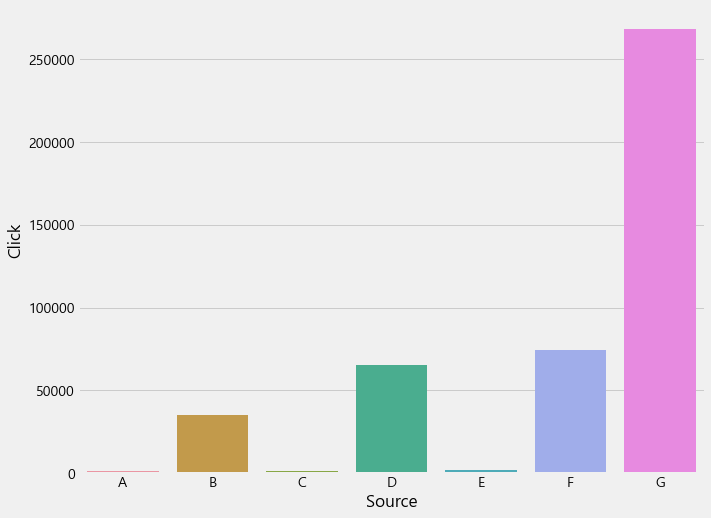

In [24]:
# Click
plt.figure(figsize=(10, 8))
df_by_group_label = df_roas.reset_index()
sns.barplot(x='Source', y='Click', data=df_by_group_label)
plt.show()

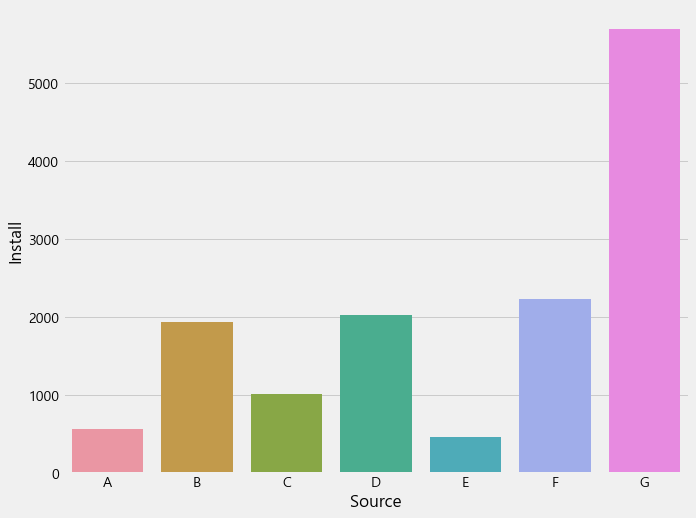

In [25]:
# Install
plt.figure(figsize=(10, 8))
df_by_group_label = df_roas.reset_index()
sns.barplot(x='Source', y='Install', data=df_by_group_label)
plt.show()

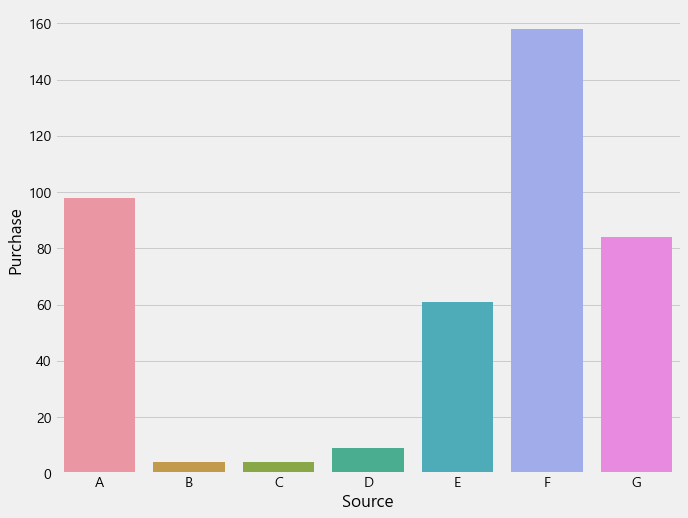

In [26]:
# Purchase
plt.figure(figsize=(10, 8))
df_by_group_label = df_roas.reset_index()
sns.barplot(x='Source', y='Purchase', data=df_by_group_label)
plt.show()

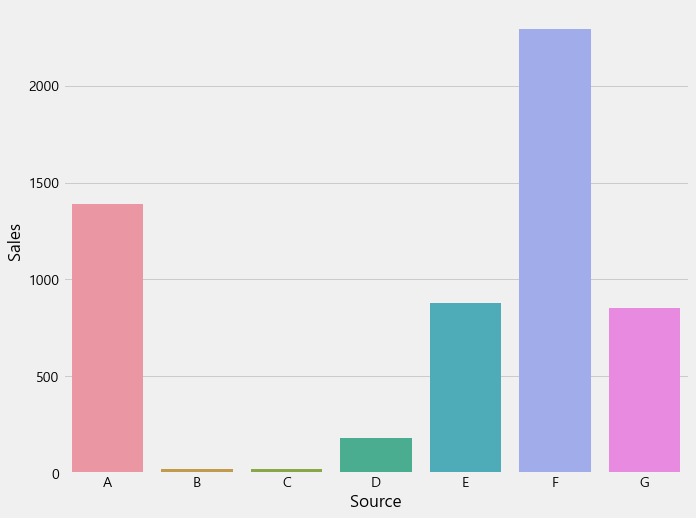

In [27]:
# Sales
plt.figure(figsize=(10, 8))
df_by_group_label = df_roas.reset_index()
sns.barplot(x='Source', y='Sales', data=df_by_group_label)
plt.show()

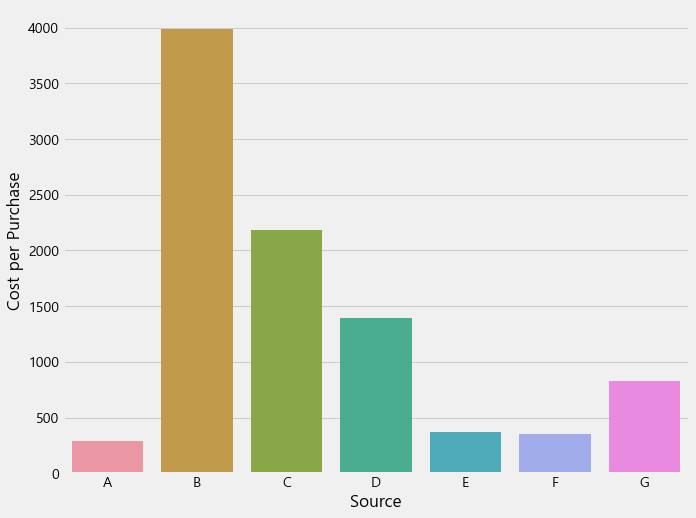

In [28]:
# Cost per Purchase
plt.figure(figsize=(10, 8))
df_by_group_label = df_roas.reset_index()
sns.barplot(x='Source', y='Cost per Purchase', data=df_by_group_label)
plt.show()

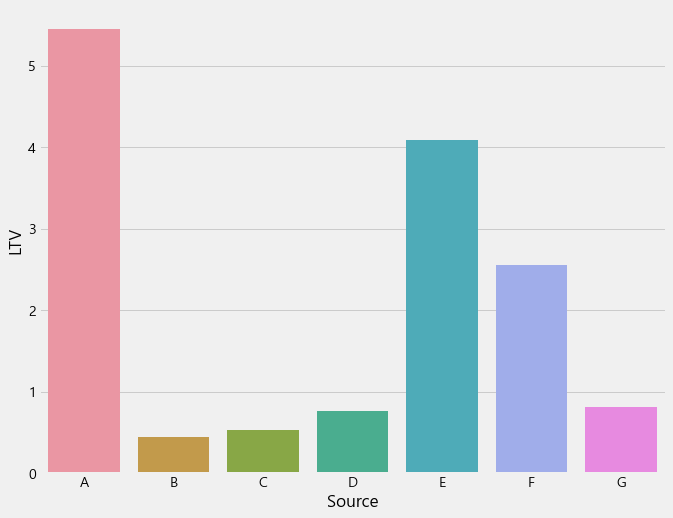

In [29]:
# LTV
plt.figure(figsize=(10, 8))
df_by_group_label = df_roas.reset_index()
sns.barplot(x='Source', y='LTV', data=df_by_group_label)
plt.show()

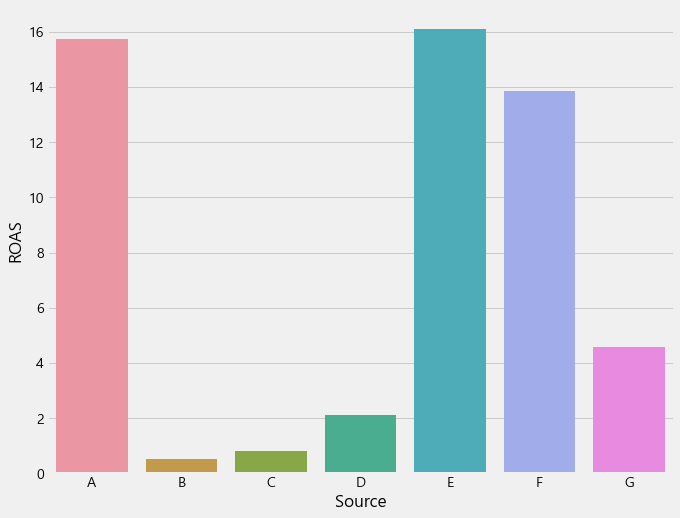

In [30]:
# ROAS
plt.figure(figsize=(10, 8))
df_by_group_label = df_roas.reset_index()
sns.barplot(x='Source', y='ROAS', data=df_by_group_label)
plt.show()

### 전체 기간 데이터 비교

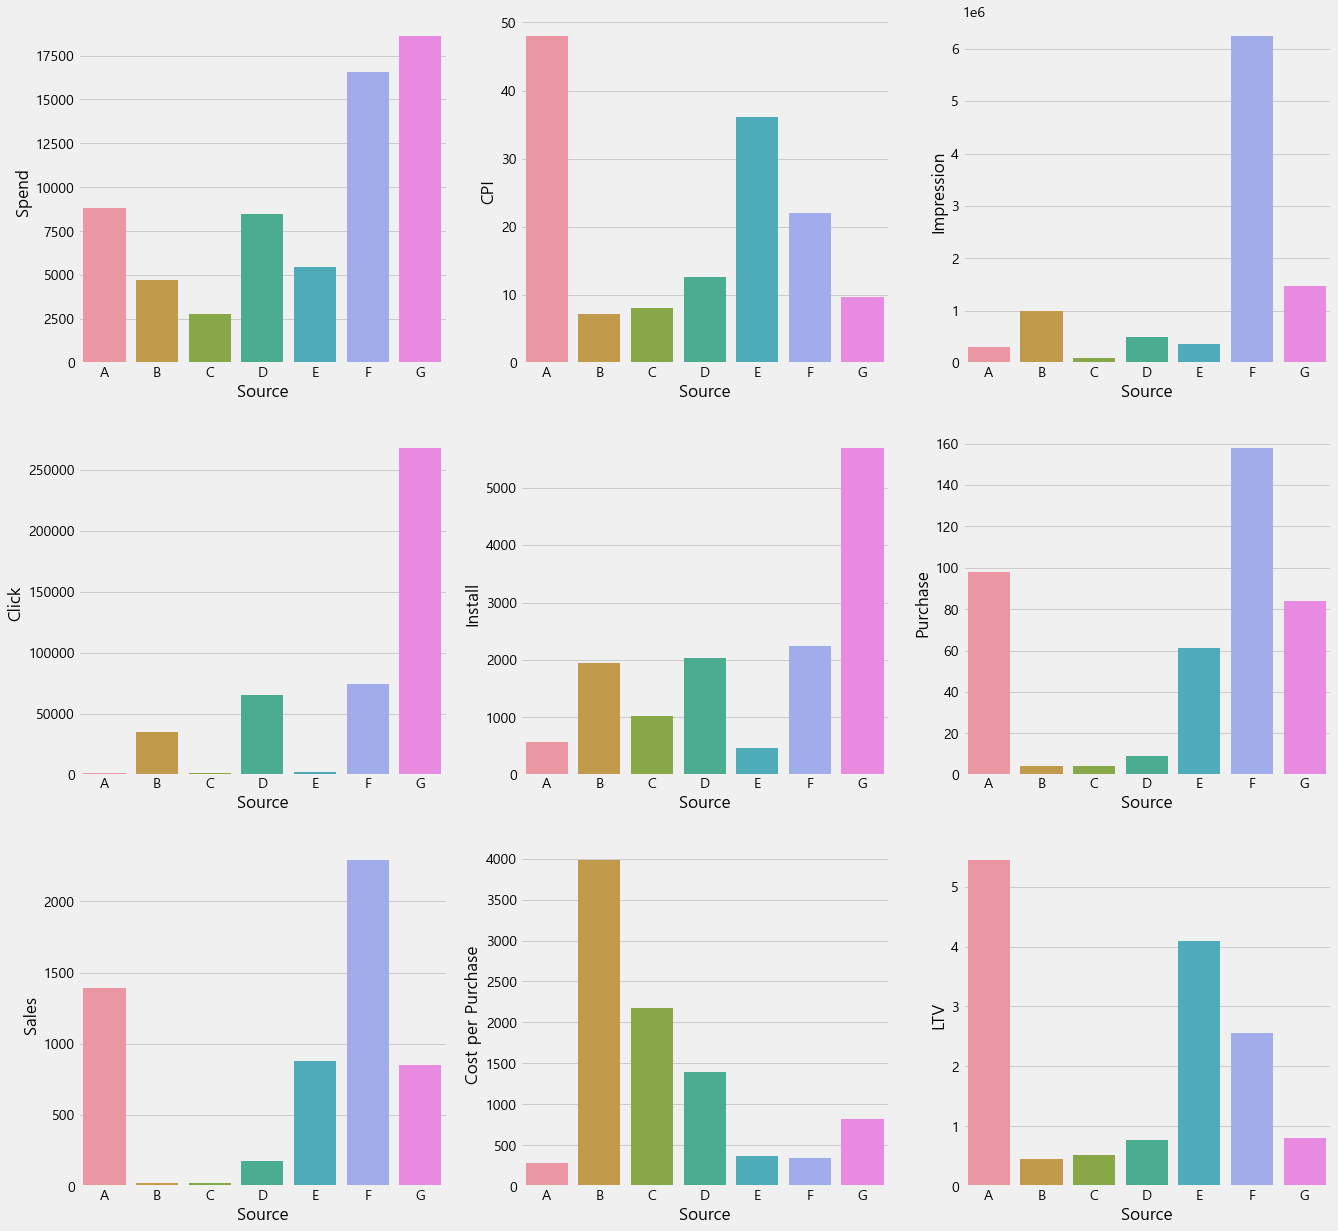

In [31]:
# 3주간 소스별 비교
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 20))
df_by_group_label = df_roas.reset_index()
sns.barplot(x='Source', y='Spend', data=df_by_group_label, ax=axes[0, 0])
sns.barplot(x='Source', y='CPI', data=df_by_group_label, ax=axes[0, 1])
sns.barplot(x='Source', y='Impression', data=df_by_group_label, ax=axes[0, 2])
sns.barplot(x='Source', y='Click', data=df_by_group_label, ax=axes[1, 0])
sns.barplot(x='Source', y='Install', data=df_by_group_label, ax=axes[1, 1])
sns.barplot(x='Source', y='Purchase', data=df_by_group_label, ax=axes[1, 2])
sns.barplot(x='Source', y='Sales', data=df_by_group_label, ax=axes[2, 0])
sns.barplot(x='Source', y='Cost per Purchase', data=df_by_group_label, ax=axes[2, 1])
sns.barplot(x='Source', y='LTV', data=df_by_group_label, ax=axes[2, 2])
plt.show()

+ 설치당 매출
+ 구매당 매출
+ 설치당 구매횟수

계산해보기

In [32]:
df_roas

,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV,ROAS
Source,,,,,,,,,,,
A,6,8835.7,47.97,307917,1279,565,98.0,1389.22,289.76,5.45,15.722806
B,6,4697.0,7.25,997312,35236,1942,4.0,23.91,3988.05,0.45,0.509048
C,6,2765.0,8.09,85860,1239,1021,4.0,22.40,2179.50,0.53,0.810127
D,6,8480.8,12.63,501990,65375,2025,9.0,179.86,1391.04,0.77,2.120790
E,6,5449.7,36.08,355096,2201,469,61.0,877.59,368.01,4.09,16.103455
F,6,16537.0,21.98,6239383,74637,2235,158.0,2292.46,349.76,2.56,13.862611
G,6,18600.0,9.74,1465891,268280,5696,84.0,850.70,827.12,0.81,4.573656


In [33]:
df_roas['설치당 매출'] = df_roas['Sales'] / df_roas['Install']
df_roas['구매당 매출'] = df_roas['Sales'] / df_roas['Purchase']
df_roas['설치당 구매횟수'] = df_roas['Purchase'] / df_roas['Install']
df_roas

,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV,ROAS,설치당 매출,구매당 매출,설치당 구매횟수
Source,,,,,,,,,,,,,,
A,6,8835.7,47.97,307917,1279,565,98.0,1389.22,289.76,5.45,15.722806,2.458796,14.175714,0.173451
B,6,4697.0,7.25,997312,35236,1942,4.0,23.91,3988.05,0.45,0.509048,0.012312,5.977500,0.002060
C,6,2765.0,8.09,85860,1239,1021,4.0,22.40,2179.50,0.53,0.810127,0.021939,5.600000,0.003918
D,6,8480.8,12.63,501990,65375,2025,9.0,179.86,1391.04,0.77,2.120790,0.088820,19.984444,0.004444
E,6,5449.7,36.08,355096,2201,469,61.0,877.59,368.01,4.09,16.103455,1.871194,14.386721,0.130064
F,6,16537.0,21.98,6239383,74637,2235,158.0,2292.46,349.76,2.56,13.862611,1.025709,14.509241,0.070694
G,6,18600.0,9.74,1465891,268280,5696,84.0,850.70,827.12,0.81,4.573656,0.149350,10.127381,0.014747


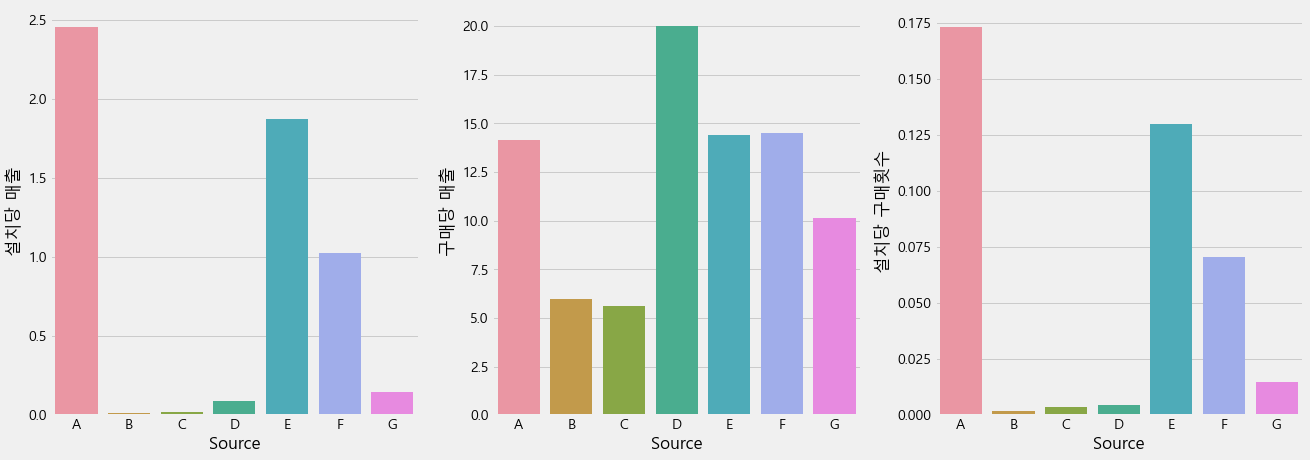

In [34]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 7))
df_by_group_label = df_roas.reset_index()
sns.barplot(x='Source', y='설치당 매출', data=df_by_group_label, ax=axes[0])
sns.barplot(x='Source', y='구매당 매출', data=df_by_group_label, ax=axes[1])
sns.barplot(x='Source', y='설치당 구매횟수', data=df_by_group_label, ax=axes[2])
plt.show()

#### 전체 데이터에 컬럼 추가하기

In [35]:
# 전체 데이터에 컬럼 추가하기
# ROAS 등등
df['ROAS'] = (df['Sales'] / df['Spend']) * 100
df['설치당 매출'] = df['Sales'] / df['Install']
df['구매당 매출'] = df['Sales'] / df['Purchase']
df['설치당 구매횟수'] = df['Purchase'] / df['Install']
df

,Source,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV,ROAS,설치당 매출,구매당 매출,설치당 구매횟수
0,A,1,3481.6,14.04,113348,491,248,49.0,715.14,71.05,2.17,20.540556,2.883629,14.594694,0.197581
1,A,2,2804.0,18.57,92149,359,151,26.0,396.69,107.84,1.98,14.147290,2.627086,15.257308,0.172185
2,A,3,2550.1,15.36,102420,429,166,23.0,277.39,110.87,1.30,10.877613,1.671024,12.060435,0.138554
3,B,1,1826.6,2.55,349493,11691,717,1.0,6.87,1826.61,0.16,0.376109,0.009582,6.870000,0.001395
4,B,2,1417.9,2.22,321994,11797,640,2.0,10.21,708.95,0.15,0.720079,0.015953,5.105000,0.003125
5,B,3,1452.5,2.48,325825,11748,585,1.0,6.83,1452.49,0.14,0.470224,0.011675,6.830000,0.001709
6,C,1,801.0,2.72,25535,359,294,1.0,6.61,801.00,0.18,0.825218,0.022483,6.610000,0.003401
7,C,2,793.0,2.59,21245,364,306,1.0,5.76,793.00,0.18,0.726356,0.018824,5.760000,0.003268
8,C,3,1171.0,2.78,39080,516,421,2.0,10.03,585.50,0.17,0.856533,0.023824,5.015000,0.004751
9,D,1,3525.4,3.93,274921,31737,897,0.0,0.00,0.00,0.21,0.000000,0.000000,NaN,0.000000


### 주차별 데이터 비교

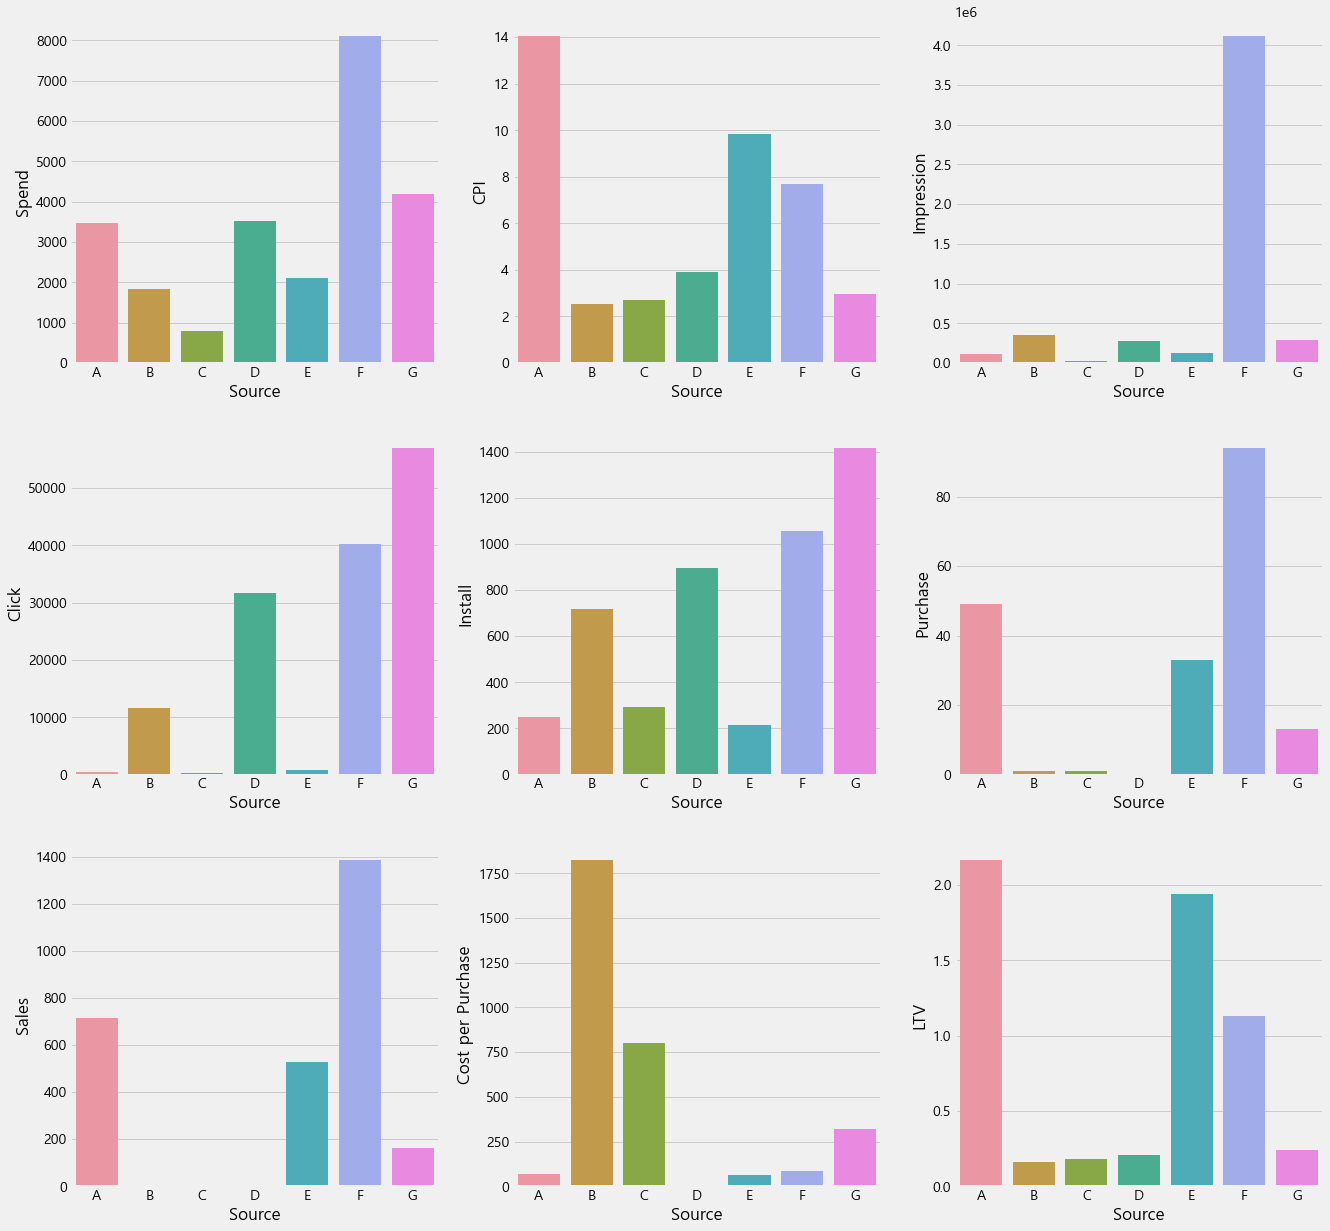

In [36]:
# 1주차 비교
df_w1 = df[df['Week']==1]
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 20))
df_by_group_label = df_w1
sns.barplot(x='Source', y='Spend', data=df_by_group_label, ax=axes[0, 0])
sns.barplot(x='Source', y='CPI', data=df_by_group_label, ax=axes[0, 1])
sns.barplot(x='Source', y='Impression', data=df_by_group_label, ax=axes[0, 2])
sns.barplot(x='Source', y='Click', data=df_by_group_label, ax=axes[1, 0])
sns.barplot(x='Source', y='Install', data=df_by_group_label, ax=axes[1, 1])
sns.barplot(x='Source', y='Purchase', data=df_by_group_label, ax=axes[1, 2])
sns.barplot(x='Source', y='Sales', data=df_by_group_label, ax=axes[2, 0])
sns.barplot(x='Source', y='Cost per Purchase', data=df_by_group_label, ax=axes[2, 1])
sns.barplot(x='Source', y='LTV', data=df_by_group_label, ax=axes[2, 2])
plt.show()

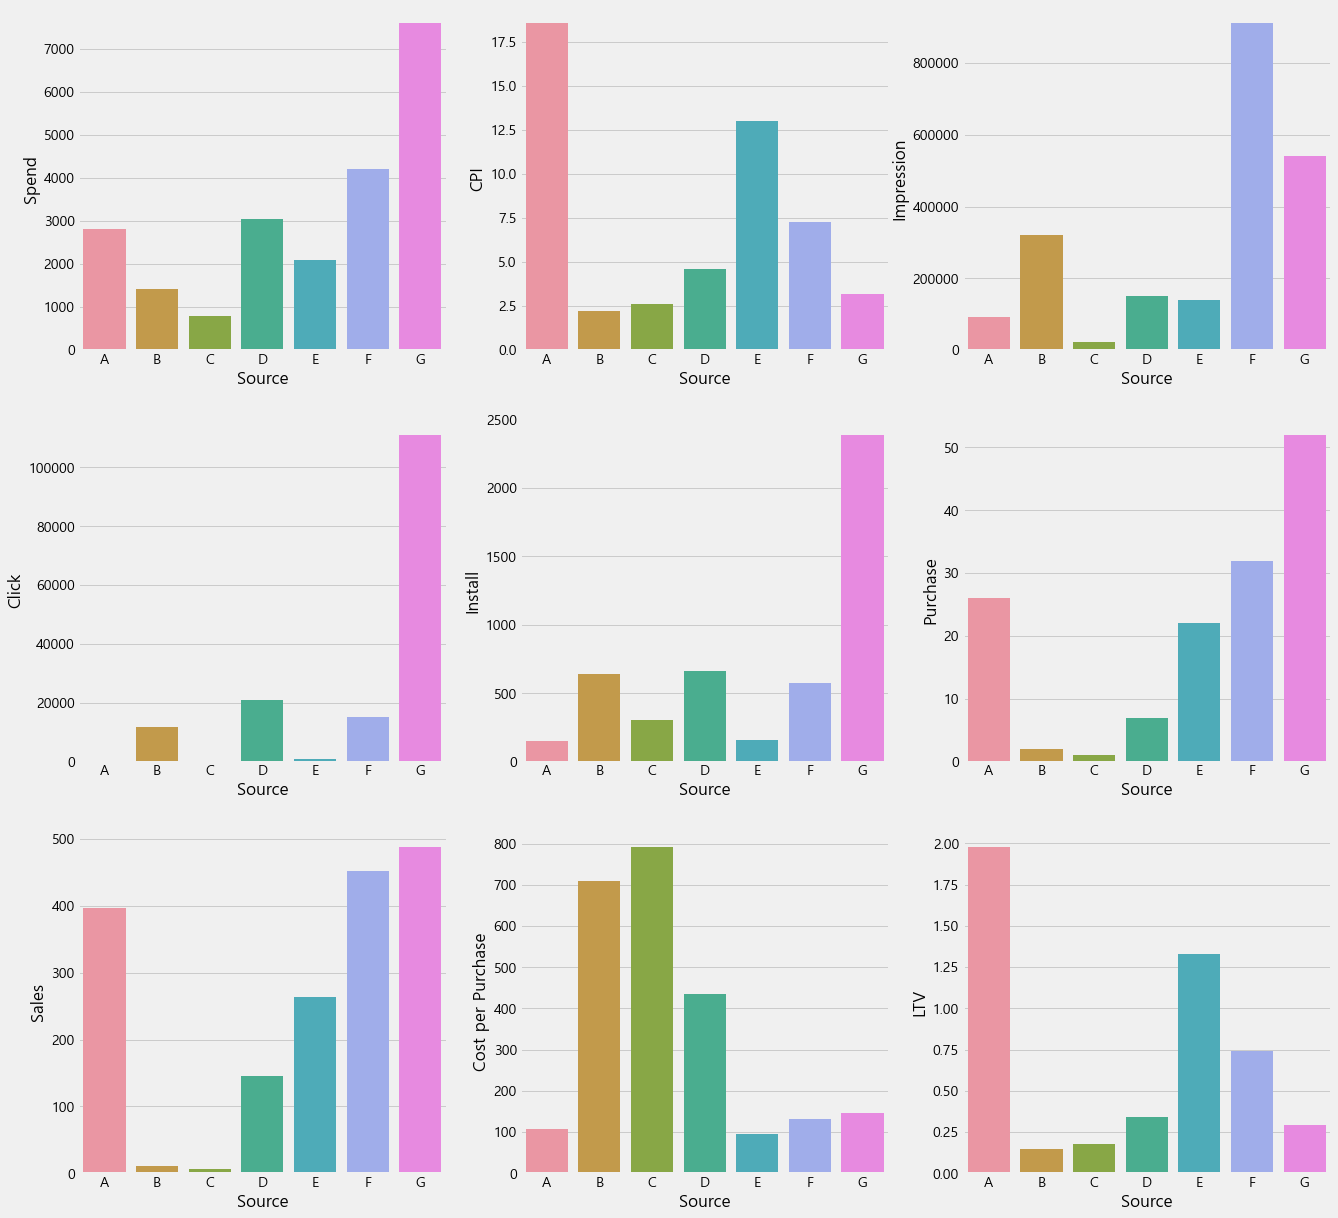

In [37]:
# 2주차 비교
df_w2 = df[df['Week']==2]
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 20))
df_by_group_label = df_w2
sns.barplot(x='Source', y='Spend', data=df_by_group_label, ax=axes[0, 0])
sns.barplot(x='Source', y='CPI', data=df_by_group_label, ax=axes[0, 1])
sns.barplot(x='Source', y='Impression', data=df_by_group_label, ax=axes[0, 2])
sns.barplot(x='Source', y='Click', data=df_by_group_label, ax=axes[1, 0])
sns.barplot(x='Source', y='Install', data=df_by_group_label, ax=axes[1, 1])
sns.barplot(x='Source', y='Purchase', data=df_by_group_label, ax=axes[1, 2])
sns.barplot(x='Source', y='Sales', data=df_by_group_label, ax=axes[2, 0])
sns.barplot(x='Source', y='Cost per Purchase', data=df_by_group_label, ax=axes[2, 1])
sns.barplot(x='Source', y='LTV', data=df_by_group_label, ax=axes[2, 2])
plt.show()

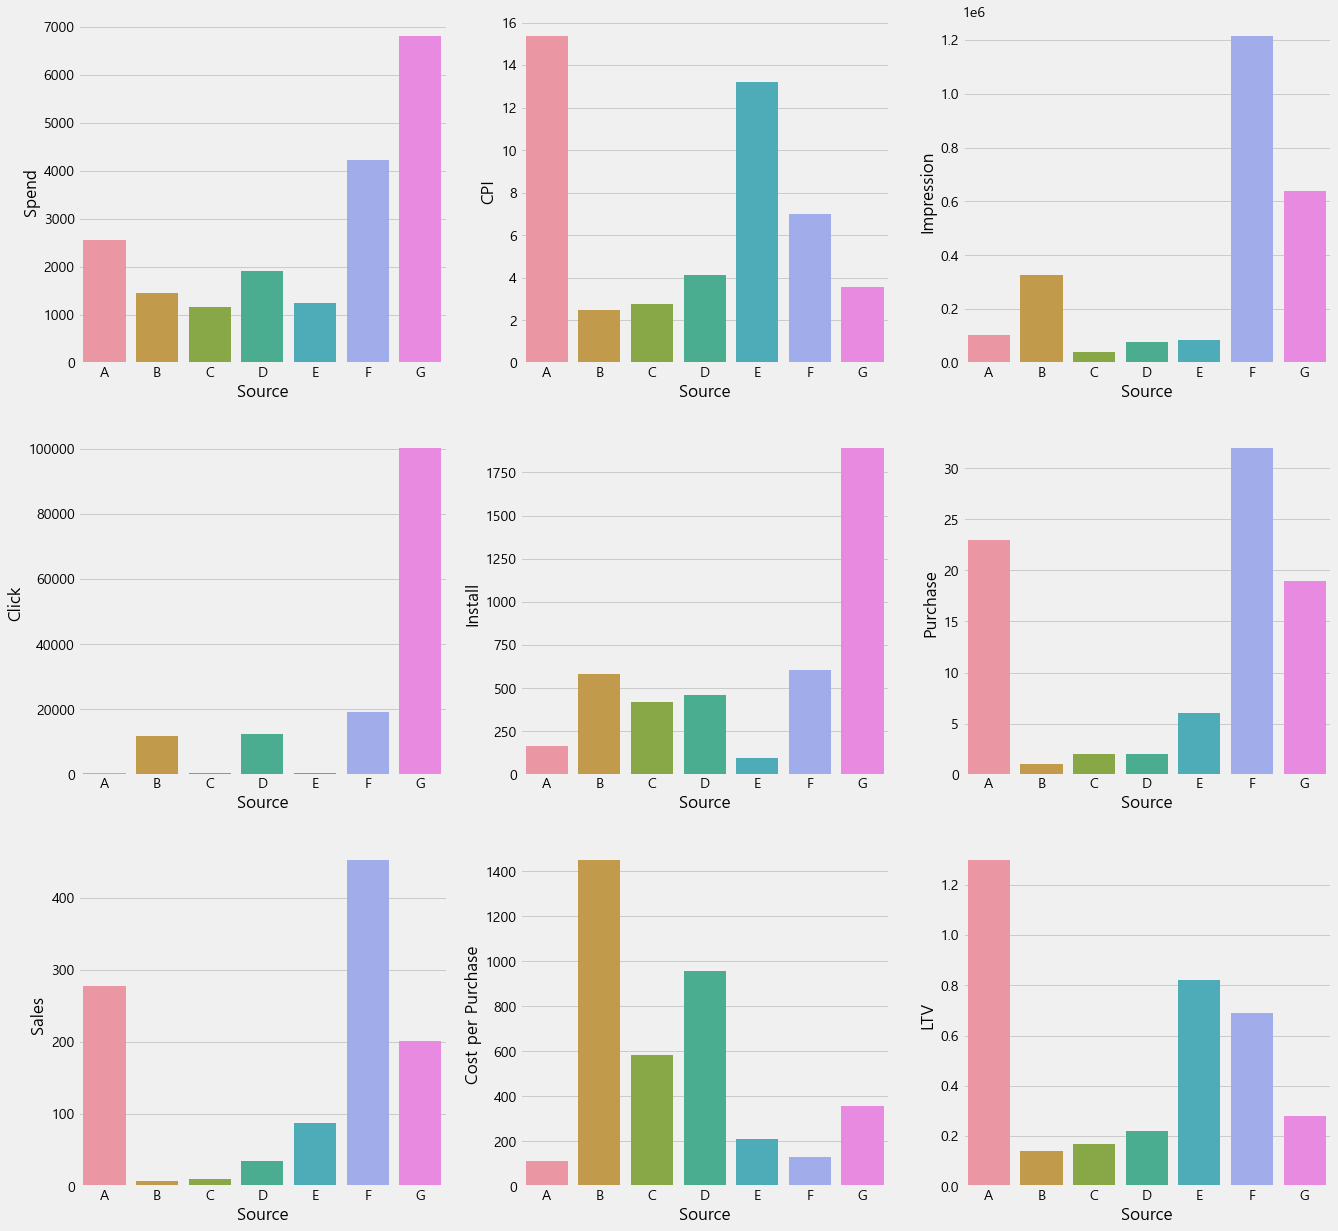

In [38]:
# 3주차 비교
df_w3 = df[df['Week']==3]
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 20))
df_by_group_label = df_w3
sns.barplot(x='Source', y='Spend', data=df_by_group_label, ax=axes[0, 0])
sns.barplot(x='Source', y='CPI', data=df_by_group_label, ax=axes[0, 1])
sns.barplot(x='Source', y='Impression', data=df_by_group_label, ax=axes[0, 2])
sns.barplot(x='Source', y='Click', data=df_by_group_label, ax=axes[1, 0])
sns.barplot(x='Source', y='Install', data=df_by_group_label, ax=axes[1, 1])
sns.barplot(x='Source', y='Purchase', data=df_by_group_label, ax=axes[1, 2])
sns.barplot(x='Source', y='Sales', data=df_by_group_label, ax=axes[2, 0])
sns.barplot(x='Source', y='Cost per Purchase', data=df_by_group_label, ax=axes[2, 1])
sns.barplot(x='Source', y='LTV', data=df_by_group_label, ax=axes[2, 2])
plt.show()

In [39]:
df

,Source,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV,ROAS,설치당 매출,구매당 매출,설치당 구매횟수
0,A,1,3481.6,14.04,113348,491,248,49.0,715.14,71.05,2.17,20.540556,2.883629,14.594694,0.197581
1,A,2,2804.0,18.57,92149,359,151,26.0,396.69,107.84,1.98,14.147290,2.627086,15.257308,0.172185
2,A,3,2550.1,15.36,102420,429,166,23.0,277.39,110.87,1.30,10.877613,1.671024,12.060435,0.138554
3,B,1,1826.6,2.55,349493,11691,717,1.0,6.87,1826.61,0.16,0.376109,0.009582,6.870000,0.001395
4,B,2,1417.9,2.22,321994,11797,640,2.0,10.21,708.95,0.15,0.720079,0.015953,5.105000,0.003125
5,B,3,1452.5,2.48,325825,11748,585,1.0,6.83,1452.49,0.14,0.470224,0.011675,6.830000,0.001709
6,C,1,801.0,2.72,25535,359,294,1.0,6.61,801.00,0.18,0.825218,0.022483,6.610000,0.003401
7,C,2,793.0,2.59,21245,364,306,1.0,5.76,793.00,0.18,0.726356,0.018824,5.760000,0.003268
8,C,3,1171.0,2.78,39080,516,421,2.0,10.03,585.50,0.17,0.856533,0.023824,5.015000,0.004751
9,D,1,3525.4,3.93,274921,31737,897,0.0,0.00,0.00,0.21,0.000000,0.000000,NaN,0.000000


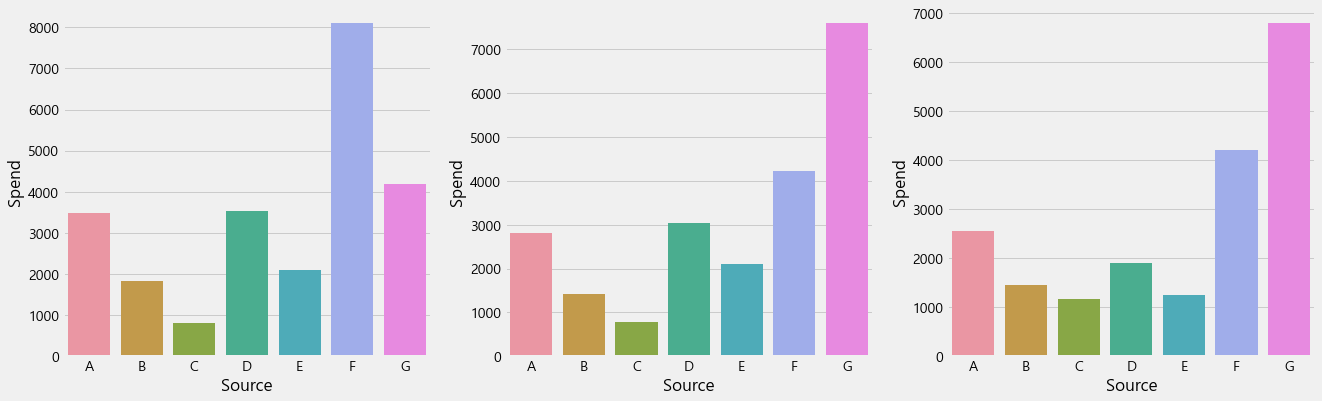

In [40]:
# 주별로 하나의 주제를 비교해보기
# Spend
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
sns.barplot(x='Source', y='Spend', data=df_w1, ax=axes[0])
sns.barplot(x='Source', y='Spend', data=df_w2, ax=axes[1])
sns.barplot(x='Source', y='Spend', data=df_w3, ax=axes[2])
plt.show()

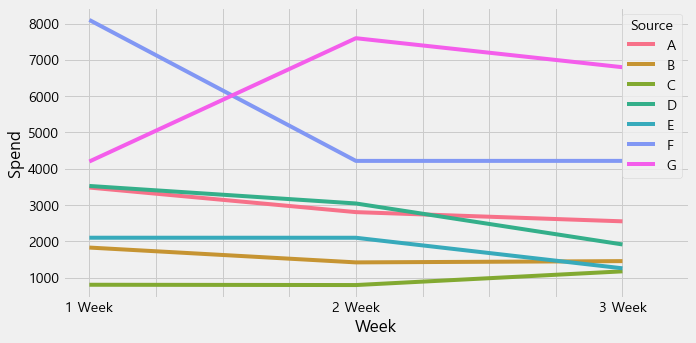

In [41]:
# 주별 비교로 선그래프 그려보기
# Spend
plt.figure(figsize=(10, 5))
sns.lineplot(x='Week', y='Spend', data=df, hue='Source', markers=True)
plt.xticks(np.arange(1, 3.5, 0.25), labels=['1 Week', '', '', '', '2 Week', '', '', '', '3 Week', ''])
plt.show()

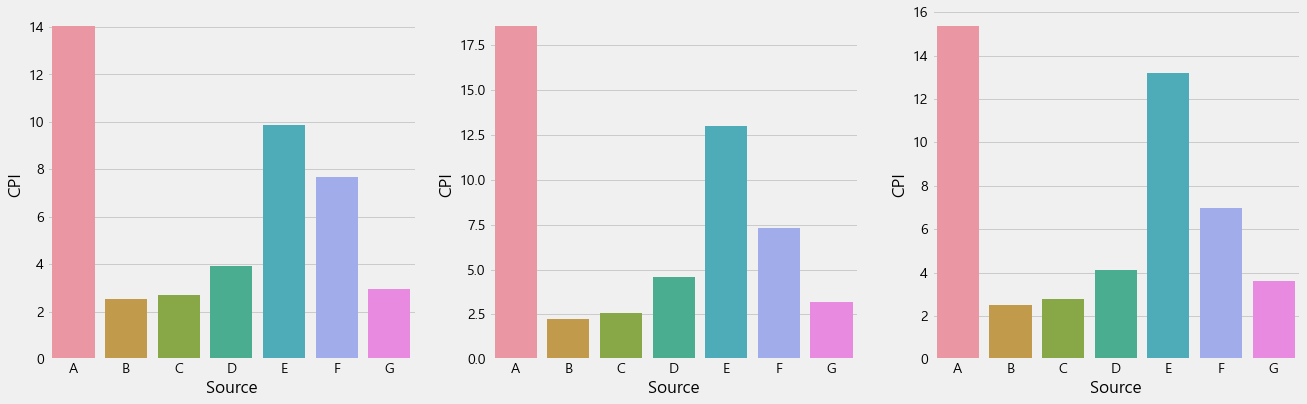

In [42]:
# 주별로 하나의 주제를 비교해보기
# CPI
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
sns.barplot(x='Source', y='CPI', data=df_w1, ax=axes[0])
sns.barplot(x='Source', y='CPI', data=df_w2, ax=axes[1])
sns.barplot(x='Source', y='CPI', data=df_w3, ax=axes[2])
plt.show()

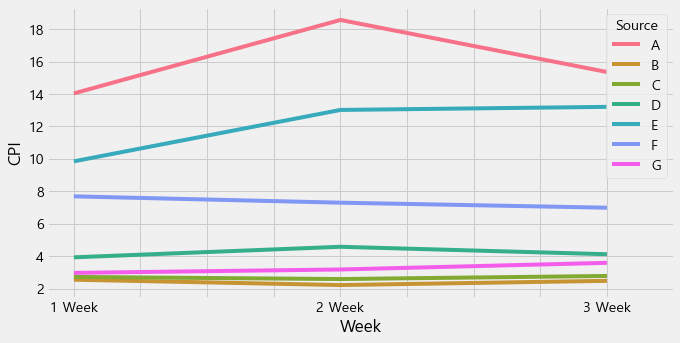

In [43]:
# CPI
plt.figure(figsize=(10, 5))
sns.lineplot(x='Week', y='CPI', data=df, hue='Source', markers=True)
plt.xticks(np.arange(1, 3.5, 0.25), labels=['1 Week', '', '', '', '2 Week', '', '', '', '3 Week', ''])
plt.show()

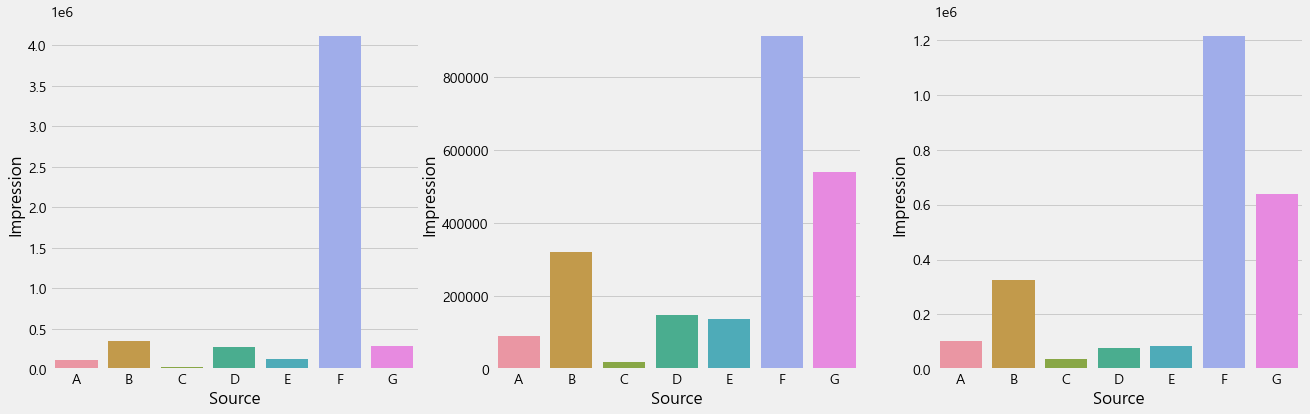

In [44]:
# 주별로 하나의 주제를 비교해보기
# Impression
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
sns.barplot(x='Source', y='Impression', data=df_w1, ax=axes[0])
sns.barplot(x='Source', y='Impression', data=df_w2, ax=axes[1])
sns.barplot(x='Source', y='Impression', data=df_w3, ax=axes[2])
plt.show()

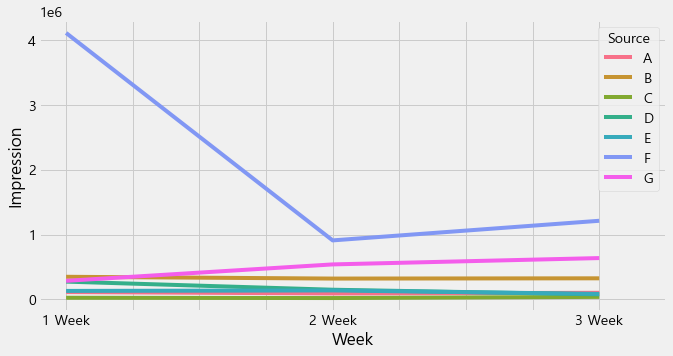

In [45]:
# Impression
plt.figure(figsize=(10, 5))
sns.lineplot(x='Week', y='Impression', data=df, hue='Source', markers=True)
plt.xticks(np.arange(1, 3.5, 0.25), labels=['1 Week', '', '', '', '2 Week', '', '', '', '3 Week', ''])
plt.show()

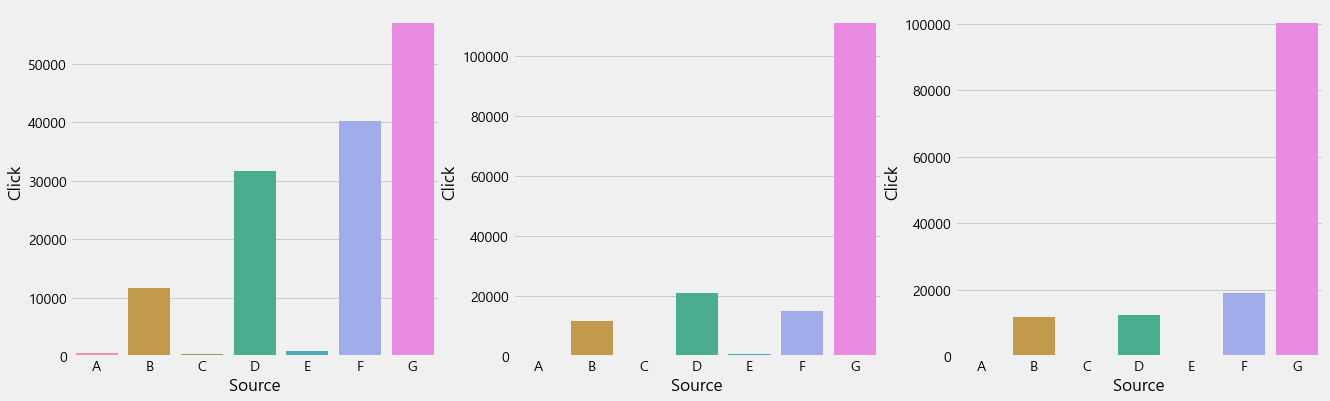

In [46]:
# 주별로 하나의 주제를 비교해보기
# Click
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
sns.barplot(x='Source', y='Click', data=df_w1, ax=axes[0])
sns.barplot(x='Source', y='Click', data=df_w2, ax=axes[1])
sns.barplot(x='Source', y='Click', data=df_w3, ax=axes[2])
plt.show()

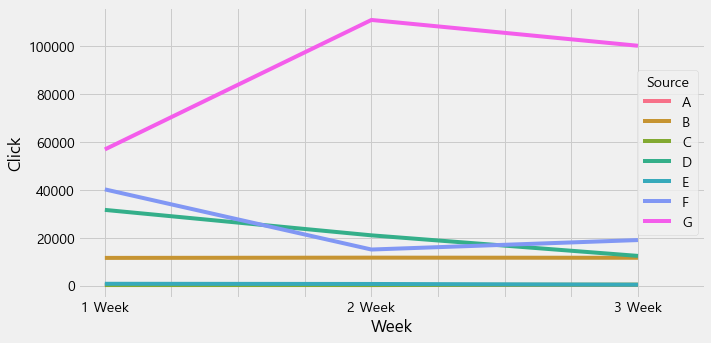

In [47]:
# Click
plt.figure(figsize=(10, 5))
sns.lineplot(x='Week', y='Click', data=df, hue='Source', markers=True)
plt.xticks(np.arange(1, 3.5, 0.25), labels=['1 Week', '', '', '', '2 Week', '', '', '', '3 Week', ''])
plt.show()

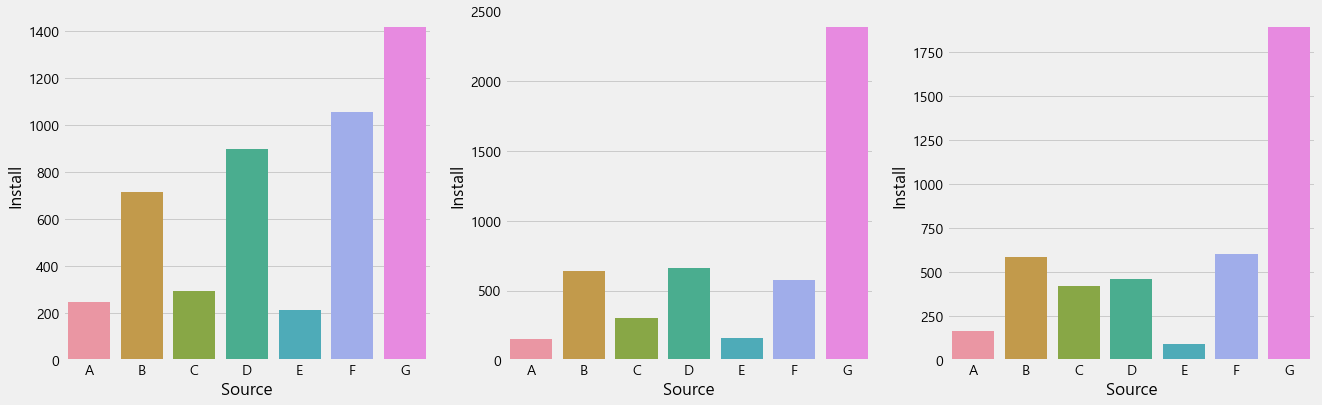

In [48]:
# 주별로 하나의 주제를 비교해보기
# Install
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
sns.barplot(x='Source', y='Install', data=df_w1, ax=axes[0])
sns.barplot(x='Source', y='Install', data=df_w2, ax=axes[1])
sns.barplot(x='Source', y='Install', data=df_w3, ax=axes[2])
plt.show()

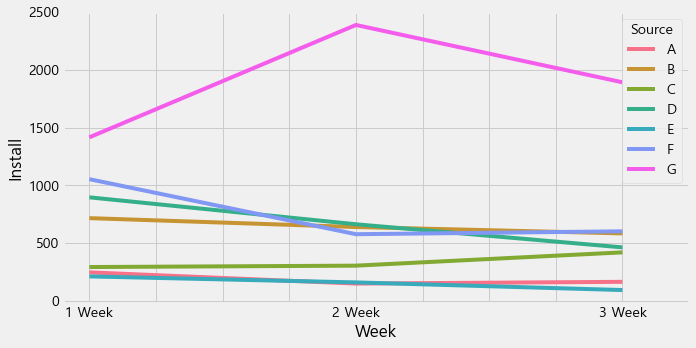

In [49]:
# Install
plt.figure(figsize=(10, 5))
sns.lineplot(x='Week', y='Install', data=df, hue='Source', markers=True)
plt.xticks(np.arange(1, 3.5, 0.25), labels=['1 Week', '', '', '', '2 Week', '', '', '', '3 Week', ''])
plt.show()

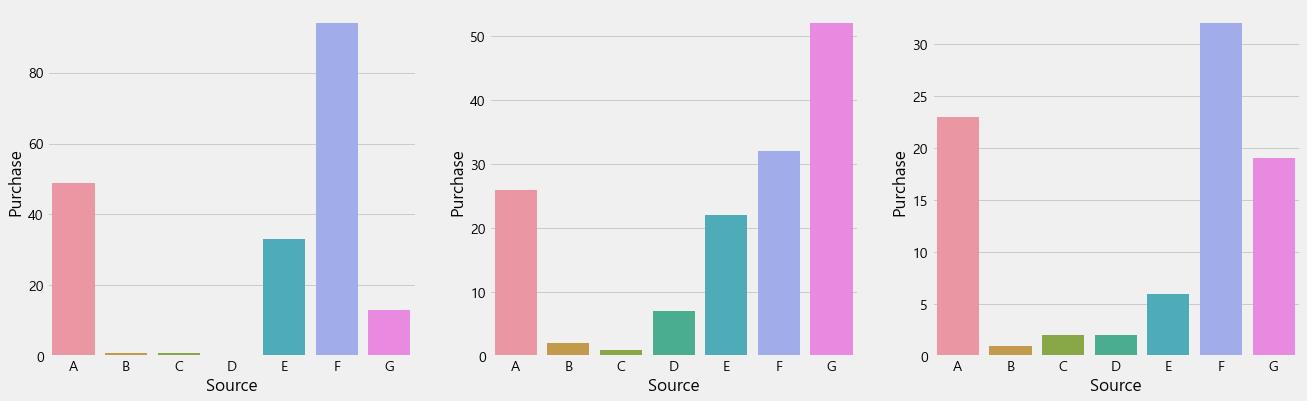

In [50]:
# 주별로 하나의 주제를 비교해보기
# Purchase
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
sns.barplot(x='Source', y='Purchase', data=df_w1, ax=axes[0])
sns.barplot(x='Source', y='Purchase', data=df_w2, ax=axes[1])
sns.barplot(x='Source', y='Purchase', data=df_w3, ax=axes[2])
plt.show()

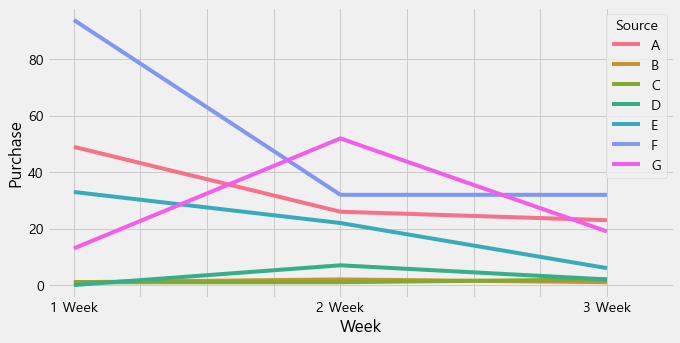

In [51]:
# Purchase
plt.figure(figsize=(10, 5))
sns.lineplot(x='Week', y='Purchase', data=df, hue='Source', markers=True)
plt.xticks(np.arange(1, 3.5, 0.25), labels=['1 Week', '', '', '', '2 Week', '', '', '', '3 Week', ''])
plt.show()

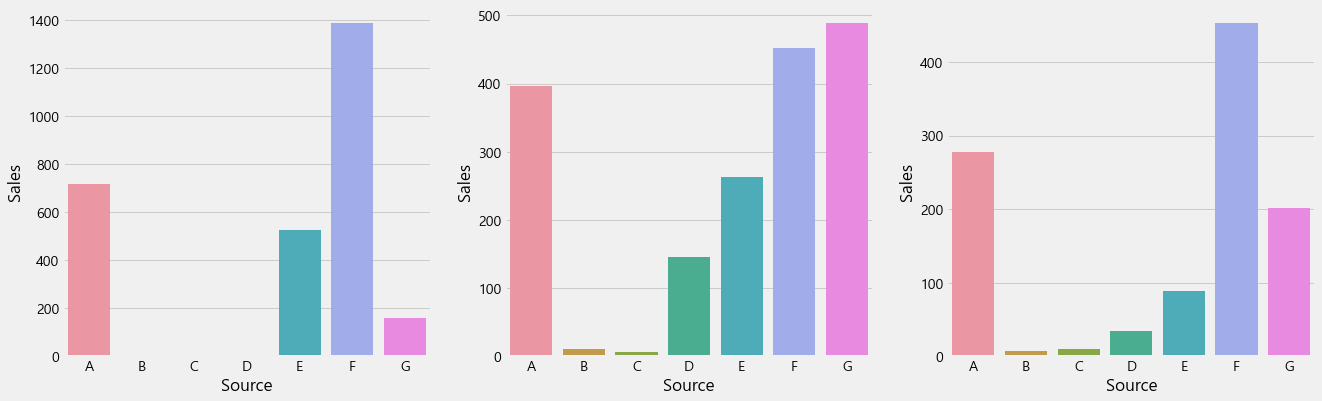

In [52]:
# 주별로 하나의 주제를 비교해보기
# Sales
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
sns.barplot(x='Source', y='Sales', data=df_w1, ax=axes[0])
sns.barplot(x='Source', y='Sales', data=df_w2, ax=axes[1])
sns.barplot(x='Source', y='Sales', data=df_w3, ax=axes[2])
plt.show()

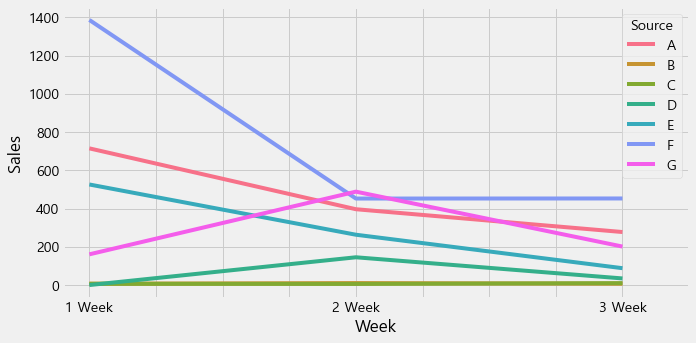

In [53]:
# Sales
plt.figure(figsize=(10, 5))
sns.lineplot(x='Week', y='Sales', data=df, hue='Source', markers=True)
plt.xticks(np.arange(1, 3.5, 0.25), labels=['1 Week', '', '', '', '2 Week', '', '', '', '3 Week', ''])
plt.show()

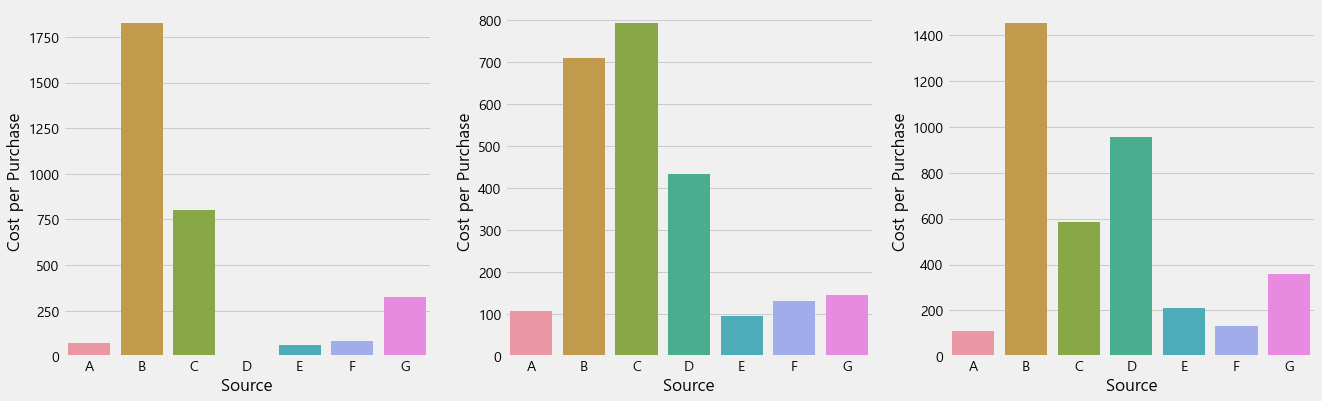

In [54]:
# 주별로 하나의 주제를 비교해보기
# Cost per Purchase
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
sns.barplot(x='Source', y='Cost per Purchase', data=df_w1, ax=axes[0])
sns.barplot(x='Source', y='Cost per Purchase', data=df_w2, ax=axes[1])
sns.barplot(x='Source', y='Cost per Purchase', data=df_w3, ax=axes[2])
plt.show()

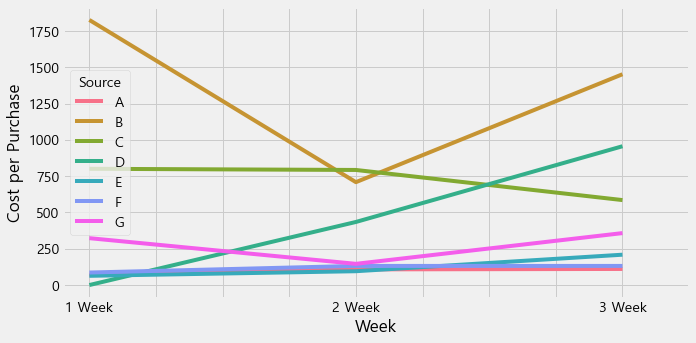

In [55]:
# Cost per Purchase
plt.figure(figsize=(10, 5))
sns.lineplot(x='Week', y='Cost per Purchase', data=df, hue='Source', markers=True)
plt.xticks(np.arange(1, 3.5, 0.25), labels=['1 Week', '', '', '', '2 Week', '', '', '', '3 Week', ''])
plt.show()

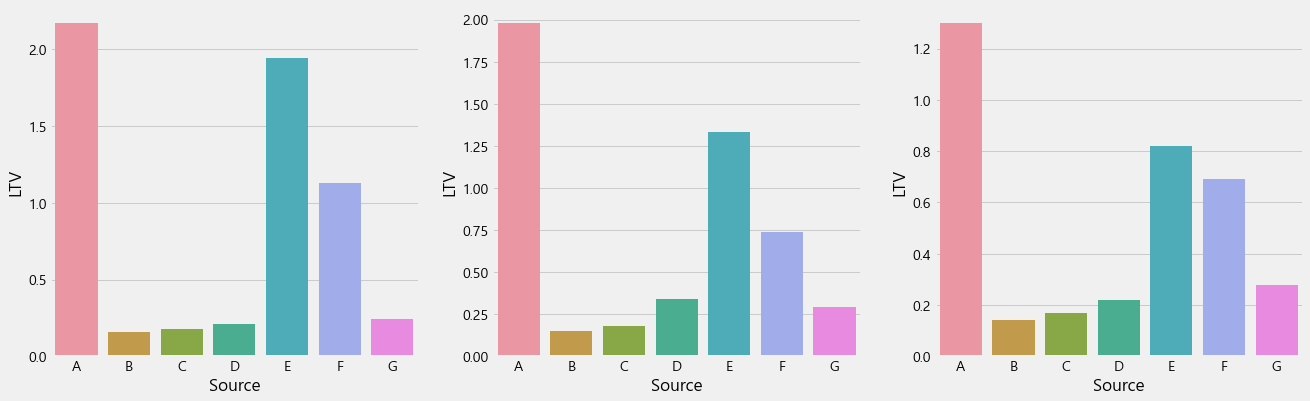

In [56]:
# 주별로 하나의 주제를 비교해보기
# LTV
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
sns.barplot(x='Source', y='LTV', data=df_w1, ax=axes[0])
sns.barplot(x='Source', y='LTV', data=df_w2, ax=axes[1])
sns.barplot(x='Source', y='LTV', data=df_w3, ax=axes[2])
plt.show()

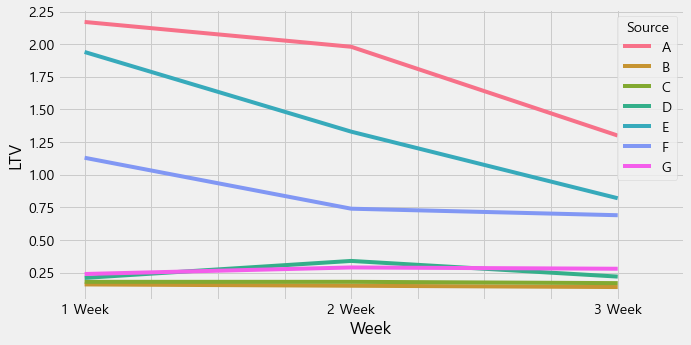

In [57]:
# LTV
plt.figure(figsize=(10, 5))
sns.lineplot(x='Week', y='LTV', data=df, hue='Source', markers=True)
plt.xticks(np.arange(1, 3.5, 0.25), labels=['1 Week', '', '', '', '2 Week', '', '', '', '3 Week', ''])
plt.show()

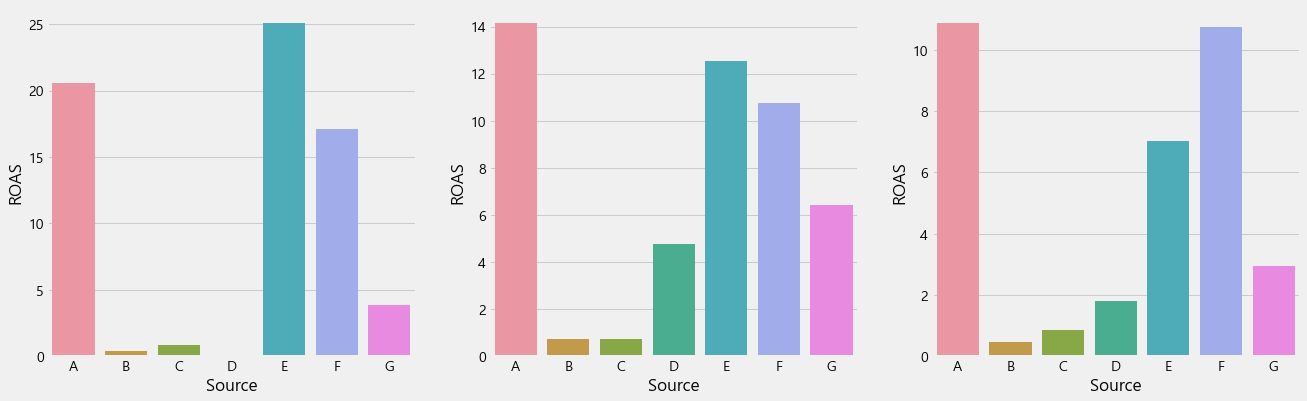

In [58]:
# 주별로 하나의 주제를 비교해보기
# ROAS
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
sns.barplot(x='Source', y='ROAS', data=df_w1, ax=axes[0])
sns.barplot(x='Source', y='ROAS', data=df_w2, ax=axes[1])
sns.barplot(x='Source', y='ROAS', data=df_w3, ax=axes[2])
plt.show()

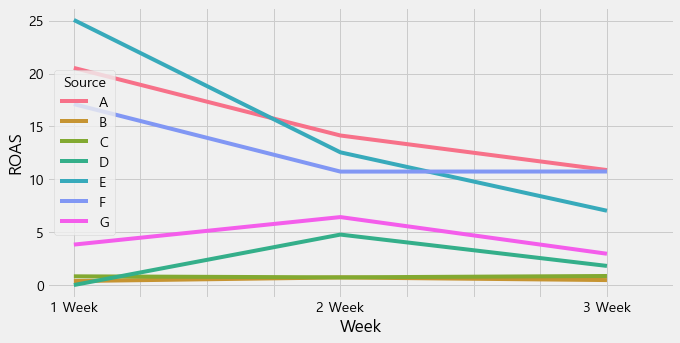

In [59]:
# ROAS
plt.figure(figsize=(10, 5))
sns.lineplot(x='Week', y='ROAS', data=df, hue='Source', markers=True)
plt.xticks(np.arange(1, 3.5, 0.25), labels=['1 Week', '', '', '', '2 Week', '', '', '', '3 Week', ''])
plt.show()

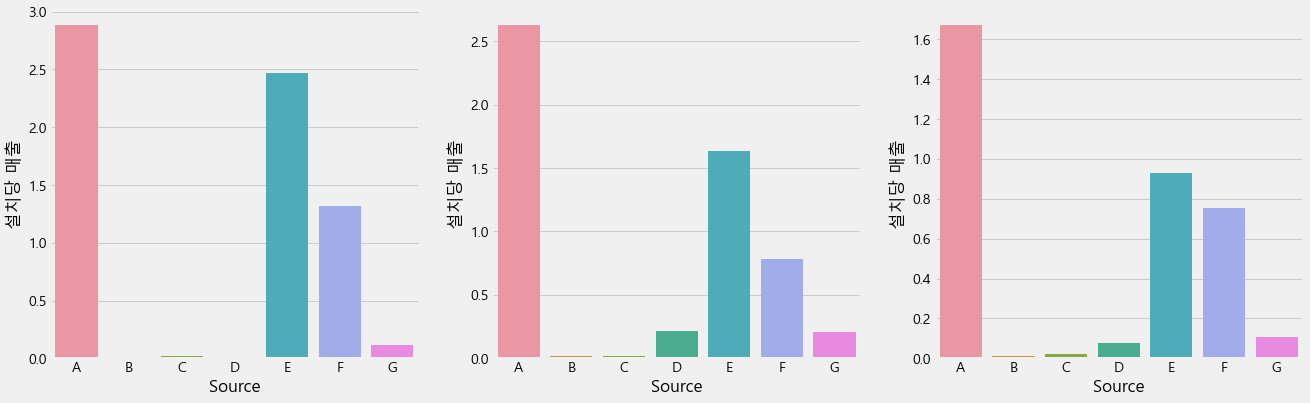

In [60]:
# 주별로 하나의 주제를 비교해보기
# 설치당 매출
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
sns.barplot(x='Source', y='설치당 매출', data=df_w1, ax=axes[0])
sns.barplot(x='Source', y='설치당 매출', data=df_w2, ax=axes[1])
sns.barplot(x='Source', y='설치당 매출', data=df_w3, ax=axes[2])
plt.show()

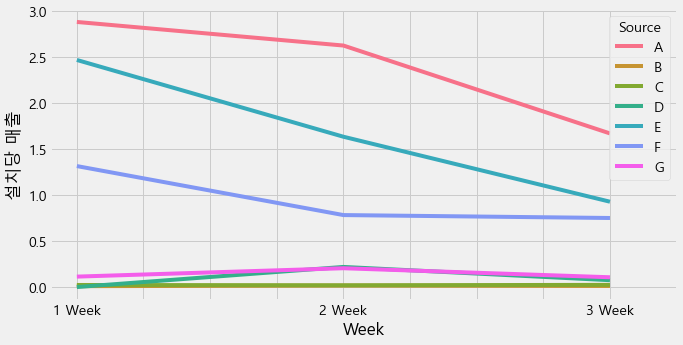

In [61]:
# 설치당 매출
plt.figure(figsize=(10, 5))
sns.lineplot(x='Week', y='설치당 매출', data=df, hue='Source', markers=True)
plt.xticks(np.arange(1, 3.5, 0.25), labels=['1 Week', '', '', '', '2 Week', '', '', '', '3 Week', ''])
plt.show()

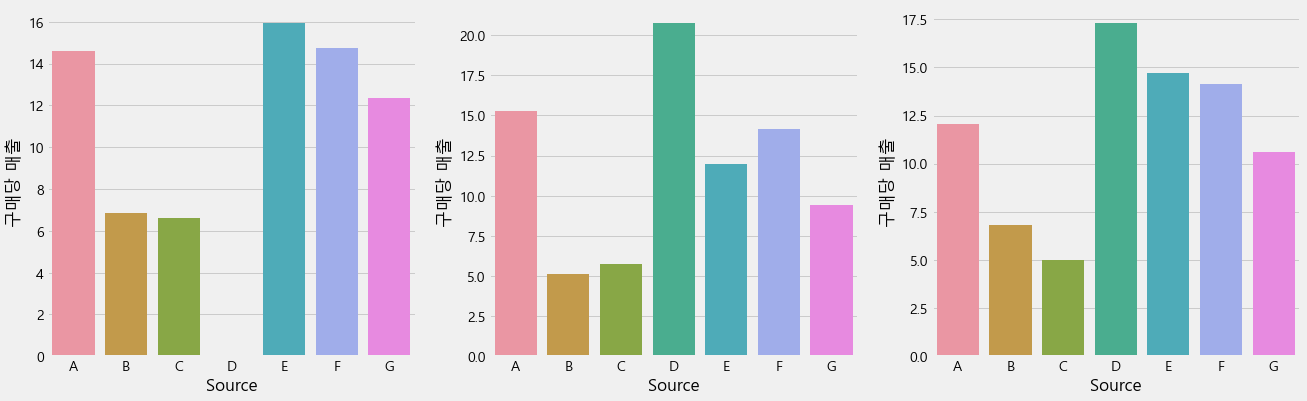

In [62]:
# 주별로 하나의 주제를 비교해보기
# 구매당 매출
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
sns.barplot(x='Source', y='구매당 매출', data=df_w1, ax=axes[0])
sns.barplot(x='Source', y='구매당 매출', data=df_w2, ax=axes[1])
sns.barplot(x='Source', y='구매당 매출', data=df_w3, ax=axes[2])
plt.show()

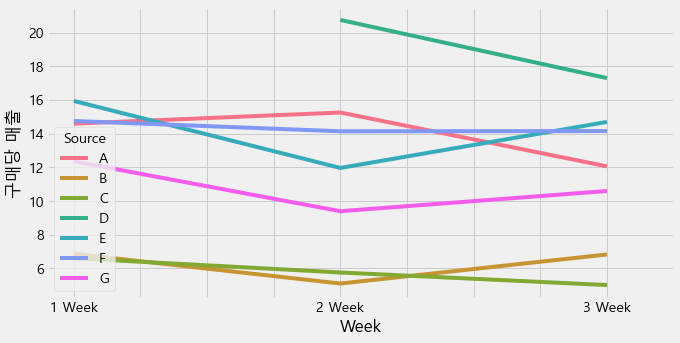

In [63]:
# 구매당 매출
plt.figure(figsize=(10, 5))
sns.lineplot(x='Week', y='구매당 매출', data=df, hue='Source', markers=True)
plt.xticks(np.arange(1, 3.5, 0.25), labels=['1 Week', '', '', '', '2 Week', '', '', '', '3 Week', ''])
plt.show()

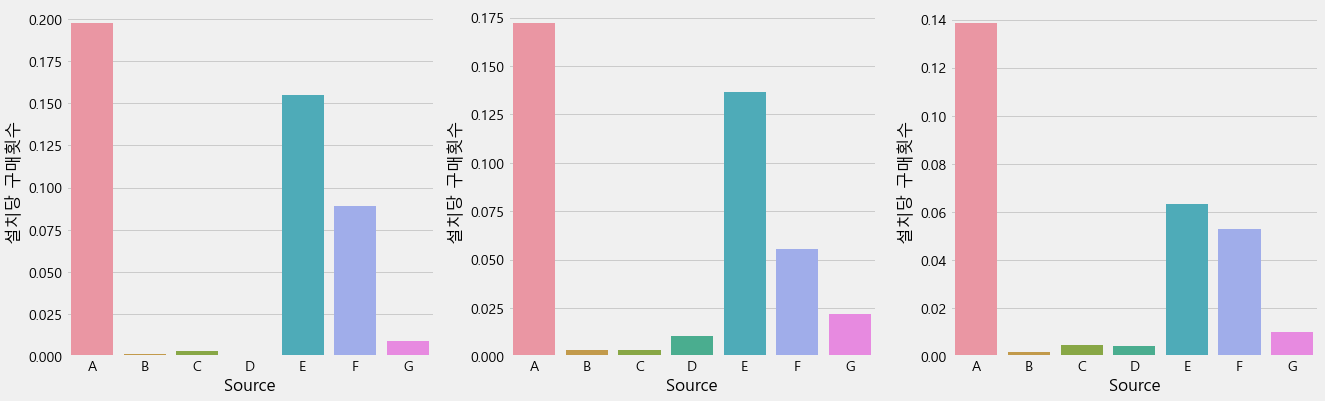

In [64]:
# 주별로 하나의 주제를 비교해보기
# 설치당 구매횟수
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
sns.barplot(x='Source', y='설치당 구매횟수', data=df_w1, ax=axes[0])
sns.barplot(x='Source', y='설치당 구매횟수', data=df_w2, ax=axes[1])
sns.barplot(x='Source', y='설치당 구매횟수', data=df_w3, ax=axes[2])
plt.show()

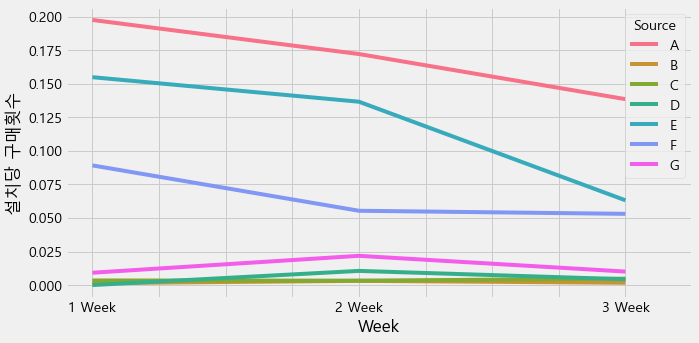

In [65]:
# 설치당 구매횟수
plt.figure(figsize=(10, 5))
sns.lineplot(x='Week', y='설치당 구매횟수', data=df, hue='Source', markers=True)
plt.xticks(np.arange(1, 3.5, 0.25), labels=['1 Week', '', '', '', '2 Week', '', '', '', '3 Week', ''])
plt.show()

In [66]:
df

,Source,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV,ROAS,설치당 매출,구매당 매출,설치당 구매횟수
0,A,1,3481.6,14.04,113348,491,248,49.0,715.14,71.05,2.17,20.540556,2.883629,14.594694,0.197581
1,A,2,2804.0,18.57,92149,359,151,26.0,396.69,107.84,1.98,14.147290,2.627086,15.257308,0.172185
2,A,3,2550.1,15.36,102420,429,166,23.0,277.39,110.87,1.30,10.877613,1.671024,12.060435,0.138554
3,B,1,1826.6,2.55,349493,11691,717,1.0,6.87,1826.61,0.16,0.376109,0.009582,6.870000,0.001395
4,B,2,1417.9,2.22,321994,11797,640,2.0,10.21,708.95,0.15,0.720079,0.015953,5.105000,0.003125
5,B,3,1452.5,2.48,325825,11748,585,1.0,6.83,1452.49,0.14,0.470224,0.011675,6.830000,0.001709
6,C,1,801.0,2.72,25535,359,294,1.0,6.61,801.00,0.18,0.825218,0.022483,6.610000,0.003401
7,C,2,793.0,2.59,21245,364,306,1.0,5.76,793.00,0.18,0.726356,0.018824,5.760000,0.003268
8,C,3,1171.0,2.78,39080,516,421,2.0,10.03,585.50,0.17,0.856533,0.023824,5.015000,0.004751
9,D,1,3525.4,3.93,274921,31737,897,0.0,0.00,0.00,0.21,0.000000,0.000000,NaN,0.000000


### 파이 그래프 그려보기

In [67]:
df_roas

,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV,ROAS,설치당 매출,구매당 매출,설치당 구매횟수
Source,,,,,,,,,,,,,,
A,6,8835.7,47.97,307917,1279,565,98.0,1389.22,289.76,5.45,15.722806,2.458796,14.175714,0.173451
B,6,4697.0,7.25,997312,35236,1942,4.0,23.91,3988.05,0.45,0.509048,0.012312,5.977500,0.002060
C,6,2765.0,8.09,85860,1239,1021,4.0,22.40,2179.50,0.53,0.810127,0.021939,5.600000,0.003918
D,6,8480.8,12.63,501990,65375,2025,9.0,179.86,1391.04,0.77,2.120790,0.088820,19.984444,0.004444
E,6,5449.7,36.08,355096,2201,469,61.0,877.59,368.01,4.09,16.103455,1.871194,14.386721,0.130064
F,6,16537.0,21.98,6239383,74637,2235,158.0,2292.46,349.76,2.56,13.862611,1.025709,14.509241,0.070694
G,6,18600.0,9.74,1465891,268280,5696,84.0,850.70,827.12,0.81,4.573656,0.149350,10.127381,0.014747


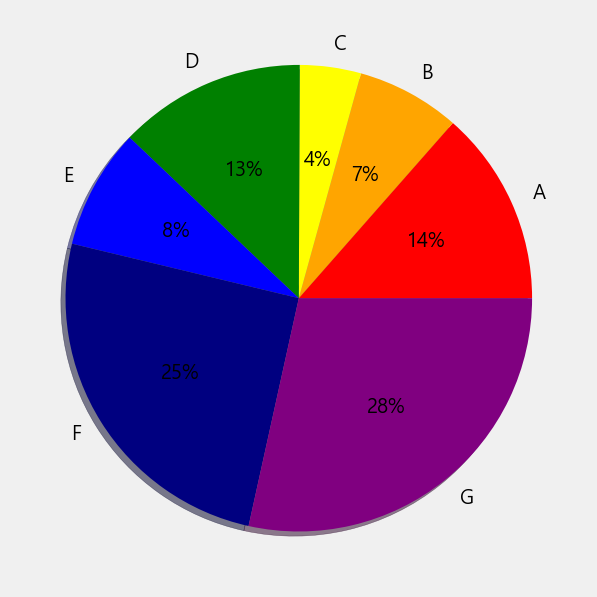

In [68]:
plt.figure(figsize=(10, 10))
plt.pie(df_roas['Spend'],
        labels=df_roas.index,
        colors=['red', 'orange', 'yellow', 'green', 'blue', 'navy', 'purple'],
        autopct='%1.0f%%',
        shadow=True,
        textprops={'fontsize':20})
plt.show()

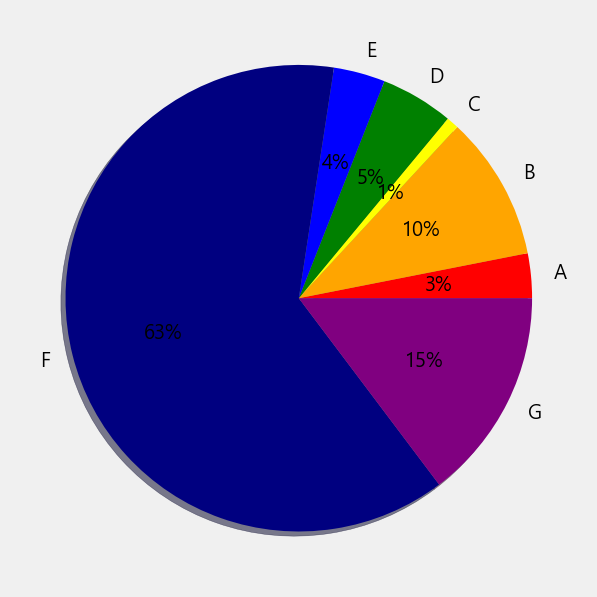

In [69]:
plt.figure(figsize=(10, 10))
plt.pie(df_roas['Impression'],
        labels=df_roas.index,
        colors=['red', 'orange', 'yellow', 'green', 'blue', 'navy', 'purple'],
        autopct='%1.0f%%',
        shadow=True,
        textprops={'fontsize':20})
plt.show()

In [70]:
# 주차별 돈 확인
df_w1.sum()[2], df_w2.sum()[2], df_w3.sum()[2]

(24036.0, 21971.199999999997, 19358.0)

In [71]:
df = df.fillna(0)
df

,Source,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV,ROAS,설치당 매출,구매당 매출,설치당 구매횟수
0,A,1,3481.6,14.04,113348,491,248,49.0,715.14,71.05,2.17,20.540556,2.883629,14.594694,0.197581
1,A,2,2804.0,18.57,92149,359,151,26.0,396.69,107.84,1.98,14.147290,2.627086,15.257308,0.172185
2,A,3,2550.1,15.36,102420,429,166,23.0,277.39,110.87,1.30,10.877613,1.671024,12.060435,0.138554
3,B,1,1826.6,2.55,349493,11691,717,1.0,6.87,1826.61,0.16,0.376109,0.009582,6.870000,0.001395
4,B,2,1417.9,2.22,321994,11797,640,2.0,10.21,708.95,0.15,0.720079,0.015953,5.105000,0.003125
5,B,3,1452.5,2.48,325825,11748,585,1.0,6.83,1452.49,0.14,0.470224,0.011675,6.830000,0.001709
6,C,1,801.0,2.72,25535,359,294,1.0,6.61,801.00,0.18,0.825218,0.022483,6.610000,0.003401
7,C,2,793.0,2.59,21245,364,306,1.0,5.76,793.00,0.18,0.726356,0.018824,5.760000,0.003268
8,C,3,1171.0,2.78,39080,516,421,2.0,10.03,585.50,0.17,0.856533,0.023824,5.015000,0.004751
9,D,1,3525.4,3.93,274921,31737,897,0.0,0.00,0.00,0.21,0.000000,0.000000,0.000000,0.000000


## 데이터 저장

In [72]:
df.to_csv('./dataset/df.csv', index=False)

In [80]:
df_roas['CPI'] = df_roas['Sales'] / df_roas['Install']
df_roas

,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV,ROAS,설치당 매출,구매당 매출,설치당 구매횟수
Source,,,,,,,,,,,,,,
A,6,8835.7,2.458796,307917,1279,565,98.0,1389.22,289.76,5.45,15.722806,2.458796,14.175714,0.173451
B,6,4697.0,0.012312,997312,35236,1942,4.0,23.91,3988.05,0.45,0.509048,0.012312,5.977500,0.002060
C,6,2765.0,0.021939,85860,1239,1021,4.0,22.40,2179.50,0.53,0.810127,0.021939,5.600000,0.003918
D,6,8480.8,0.088820,501990,65375,2025,9.0,179.86,1391.04,0.77,2.120790,0.088820,19.984444,0.004444
E,6,5449.7,1.871194,355096,2201,469,61.0,877.59,368.01,4.09,16.103455,1.871194,14.386721,0.130064
F,6,16537.0,1.025709,6239383,74637,2235,158.0,2292.46,349.76,2.56,13.862611,1.025709,14.509241,0.070694
G,6,18600.0,0.149350,1465891,268280,5696,84.0,850.70,827.12,0.81,4.573656,0.149350,10.127381,0.014747


In [81]:
df_roas.corr()

,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV,ROAS,설치당 매출,구매당 매출,설치당 구매횟수
Week,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Spend,NaN,1.000000,-0.000556,0.651750,0.808205,0.763292,0.745012,0.657664,-0.518368,0.014641,0.237646,-0.000556,0.285260,0.005354
CPI,NaN,-0.000556,1.000000,0.007312,-0.399661,-0.517222,0.550032,0.598542,-0.664550,0.999262,0.931675,1.000000,0.382367,0.999550
Impression,NaN,0.651750,0.007312,1.000000,0.234052,0.250705,0.753992,0.770706,-0.275905,0.012489,0.307982,0.007312,0.159631,-0.001057
Click,NaN,0.808205,-0.399661,0.234052,1.000000,0.987031,0.256287,0.114933,-0.152710,-0.391699,-0.233687,-0.399661,-0.018230,-0.386377
Install,NaN,0.763292,-0.517222,0.250705,0.987031,1.000000,0.179819,0.040876,-0.007395,-0.509879,-0.355354,-0.517222,-0.113404,-0.504179
Purchase,NaN,0.745012,0.550032,0.753992,0.256287,0.179819,1.000000,0.986565,-0.732804,0.558085,0.756071,0.550032,0.316226,0.551548
Sales,NaN,0.657664,0.598542,0.770706,0.114933,0.040876,0.986565,1.000000,-0.728306,0.606822,0.797171,0.598542,0.378336,0.596106
Cost per Purchase,NaN,-0.518368,-0.664550,-0.275905,-0.152710,-0.007395,-0.732804,-0.728306,1.000000,-0.676562,-0.786981,-0.664550,-0.642045,-0.663465
LTV,NaN,0.014641,0.999262,0.012489,-0.391699,-0.509879,0.558085,0.606822,-0.676562,1.000000,0.929247,0.999262,0.401547,0.998753


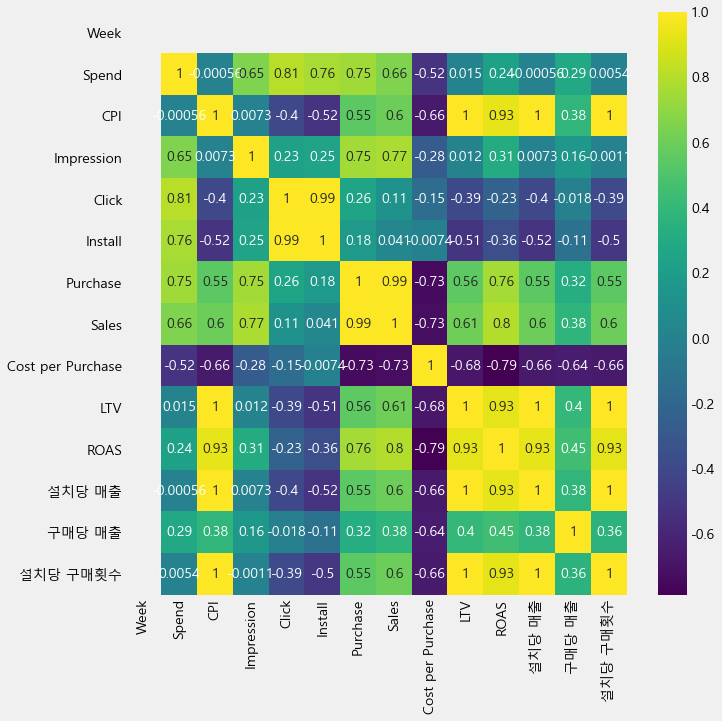

In [82]:
plt.figure(figsize=(10, 10))
sns.heatmap(df_roas.corr(), annot = True, cmap = 'viridis')
plt.show()

In [83]:
df_roas.corr()

,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV,ROAS,설치당 매출,구매당 매출,설치당 구매횟수
Week,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Spend,NaN,1.000000,-0.000556,0.651750,0.808205,0.763292,0.745012,0.657664,-0.518368,0.014641,0.237646,-0.000556,0.285260,0.005354
CPI,NaN,-0.000556,1.000000,0.007312,-0.399661,-0.517222,0.550032,0.598542,-0.664550,0.999262,0.931675,1.000000,0.382367,0.999550
Impression,NaN,0.651750,0.007312,1.000000,0.234052,0.250705,0.753992,0.770706,-0.275905,0.012489,0.307982,0.007312,0.159631,-0.001057
Click,NaN,0.808205,-0.399661,0.234052,1.000000,0.987031,0.256287,0.114933,-0.152710,-0.391699,-0.233687,-0.399661,-0.018230,-0.386377
Install,NaN,0.763292,-0.517222,0.250705,0.987031,1.000000,0.179819,0.040876,-0.007395,-0.509879,-0.355354,-0.517222,-0.113404,-0.504179
Purchase,NaN,0.745012,0.550032,0.753992,0.256287,0.179819,1.000000,0.986565,-0.732804,0.558085,0.756071,0.550032,0.316226,0.551548
Sales,NaN,0.657664,0.598542,0.770706,0.114933,0.040876,0.986565,1.000000,-0.728306,0.606822,0.797171,0.598542,0.378336,0.596106
Cost per Purchase,NaN,-0.518368,-0.664550,-0.275905,-0.152710,-0.007395,-0.732804,-0.728306,1.000000,-0.676562,-0.786981,-0.664550,-0.642045,-0.663465
LTV,NaN,0.014641,0.999262,0.012489,-0.391699,-0.509879,0.558085,0.606822,-0.676562,1.000000,0.929247,0.999262,0.401547,0.998753


In [84]:
df_roas_

,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,LTV,ROAS,설치당 매출,구매당 매출,설치당 구매횟수
Source,,,,,,,,,,,,,,
A,6,8835.7,2.458796,307917,1279,565,98.0,1389.22,289.76,5.45,15.722806,2.458796,14.175714,0.173451
B,6,4697.0,0.012312,997312,35236,1942,4.0,23.91,3988.05,0.45,0.509048,0.012312,5.977500,0.002060
C,6,2765.0,0.021939,85860,1239,1021,4.0,22.40,2179.50,0.53,0.810127,0.021939,5.600000,0.003918
D,6,8480.8,0.088820,501990,65375,2025,9.0,179.86,1391.04,0.77,2.120790,0.088820,19.984444,0.004444
E,6,5449.7,1.871194,355096,2201,469,61.0,877.59,368.01,4.09,16.103455,1.871194,14.386721,0.130064
F,6,16537.0,1.025709,6239383,74637,2235,158.0,2292.46,349.76,2.56,13.862611,1.025709,14.509241,0.070694
G,6,18600.0,0.149350,1465891,268280,5696,84.0,850.70,827.12,0.81,4.573656,0.149350,10.127381,0.014747


In [85]:
df_roas.columns

Index(['Week', 'Spend', 'CPI', 'Impression', 'Click', 'Install', 'Purchase',
       'Sales', 'Cost per Purchase', 'LTV', 'ROAS', '설치당 매출', '구매당 매출',
       '설치당 구매횟수'],
      dtype='object')

In [90]:
df_roas_1 = df_roas[['Week', 'Spend', 'CPI', 'Impression', 'Click', 'Install', 'Purchase',
       'Sales', 'Cost per Purchase', 'ROAS', '설치당 매출', '구매당 매출',
       '설치당 구매횟수']]

df_roas_1.corr()

,Week,Spend,CPI,Impression,Click,Install,Purchase,Sales,Cost per Purchase,ROAS,설치당 매출,구매당 매출,설치당 구매횟수
Week,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Spend,NaN,1.000000,-0.000556,0.651750,0.808205,0.763292,0.745012,0.657664,-0.518368,0.237646,-0.000556,0.285260,0.005354
CPI,NaN,-0.000556,1.000000,0.007312,-0.399661,-0.517222,0.550032,0.598542,-0.664550,0.931675,1.000000,0.382367,0.999550
Impression,NaN,0.651750,0.007312,1.000000,0.234052,0.250705,0.753992,0.770706,-0.275905,0.307982,0.007312,0.159631,-0.001057
Click,NaN,0.808205,-0.399661,0.234052,1.000000,0.987031,0.256287,0.114933,-0.152710,-0.233687,-0.399661,-0.018230,-0.386377
Install,NaN,0.763292,-0.517222,0.250705,0.987031,1.000000,0.179819,0.040876,-0.007395,-0.355354,-0.517222,-0.113404,-0.504179
Purchase,NaN,0.745012,0.550032,0.753992,0.256287,0.179819,1.000000,0.986565,-0.732804,0.756071,0.550032,0.316226,0.551548
Sales,NaN,0.657664,0.598542,0.770706,0.114933,0.040876,0.986565,1.000000,-0.728306,0.797171,0.598542,0.378336,0.596106
Cost per Purchase,NaN,-0.518368,-0.664550,-0.275905,-0.152710,-0.007395,-0.732804,-0.728306,1.000000,-0.786981,-0.664550,-0.642045,-0.663465
ROAS,NaN,0.237646,0.931675,0.307982,-0.233687,-0.355354,0.756071,0.797171,-0.786981,1.000000,0.931675,0.452858,0.928046


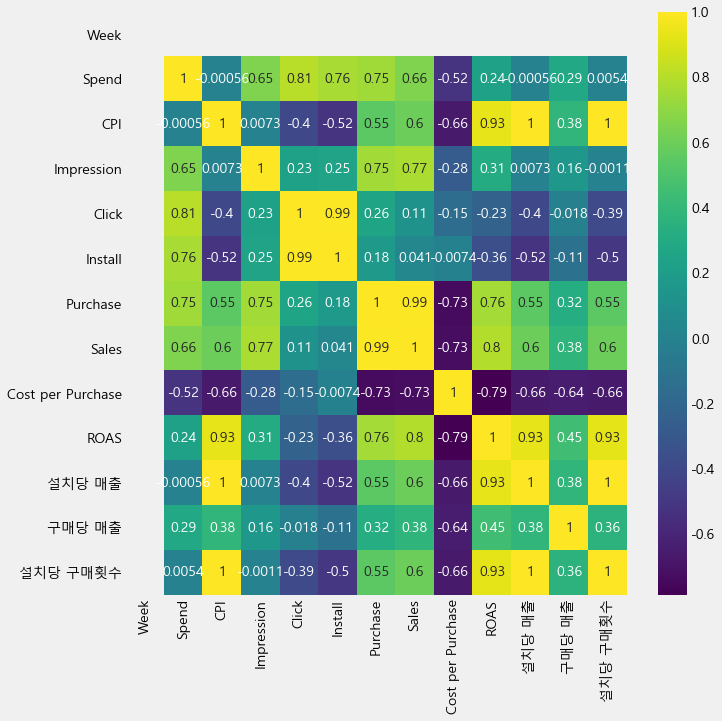

In [91]:
plt.figure(figsize=(10, 10))
sns.heatmap(df_roas_1.corr(), annot = True, cmap = 'viridis')
plt.show()